<a href="https://colab.research.google.com/github/johnsiega/1st-year--JRU/blob/main/PT_P3_Simple_and_Multiple_Linear_Regression_Siega.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Data Pipeline of WHO life expectancy data breakdown


##CELL 1: Load and Inspect Data
Purpose
Load the dataset and perform initial exploration to understand structure, data types, and quality issues.

**Input**

CSV file: Life_Expectancy_Data_-_Life_Expectancy_Data_csv.csv

**Output**

DataFrame shape (rows × columns)
Data types for each column
First 5 rows preview
Basic statistics (mean, std, min, max)
Missing value counts and percentages

**Line-by-Line Explanation**



1.   `import pandas as pd`- Import pandas for data manipulation
1.   `import numpy as np` - Import numpy for numerical operations
1.   `import matplotlib.pyplot as plt` - Import plotting library
1.   `import seaborn as sns` - Import advanced visualization library
1.   `df = pd.read_csv(...)` - Load CSV into DataFrame
2.   `print(f"Dataset Shape: {df.shape}")` - Display (rows, columns)
2.   `print(df.dtypes) `- Show data type of each column
2.  ` print(df.head())` - Preview first 5 rows
2.   `print(df.describe())` - Show summary statistics for numerical columns
2.   `print(df.isnull().sum())` - Count missing values per column




In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WHO_DATASET.csv.csv.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumn Names and Data Types:")
print(df.dtypes)
print(f"\nFirst 5 Rows:")
print(df.head())
print(f"\nBasic Statistics:")
print(df.describe())
print(f"\nMissing Values Count:")
print(df.isnull().sum())
print(f"\nMissing Values Percentage:")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0])

Dataset Shape: (2938, 22)

Column Names and Data Types:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float6

##CELL 2: Check for Duplicates
**Purpose**
Identify and remove duplicate country-year combinations to ensure data integrity.

**Input**

Raw DataFrame with potential duplicates

**Output**

Number of duplicate rows found
DataFrame with duplicates removed

**Line-by-Line Explanation**


1.   `duplicates = df.duplicated(subset=['Country', 'Year'], keep=False)` - Mark all duplicate rows based on Country+Year combination
1.   `num_duplicates = duplicates.sum()` - Count total duplicate rows
1.   `if num_duplicates > 0: `- Check if duplicates exist
2.   `df.drop_duplicates(subset=['Country', 'Year'], keep='first') `- Remove duplicates, keeping first occurrence
2.   `print(f"New shape: {df.shape}") `- Confirm new dataset size

**Why?** Each country-year should appear only once. Duplicates would bias regression coefficients.






In [ ]:
duplicates = df.duplicated(subset=['Country', 'Year'], keep=False)
num_duplicates = duplicates.sum()

print(f"Number of duplicate rows: {num_duplicates}")

if num_duplicates > 0:
    df = df.drop_duplicates(subset=['Country', 'Year'], keep='first')
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

Number of duplicate rows: 0
No duplicates found.


##CELL 3: Missing Values - Analysis
**Purpose**
Analyze patterns of missing data to determine appropriate handling strategy.

**Input**

DataFrame with potential missing values

**Output**

Table showing columns with missing data, counts, and percentages
Bar chart visualization of missing value percentages

**Line-by-Line Explanation**



1.   `missing_stats = pd.DataFrame({...})` - Create DataFrame with missing value statistics
1.   'Missing_Count': df.isnull().sum() - Count NaN values per column
1.   'Missing_Percentage': (df.isnull().sum() / len(df)) * 100 - Calculate percentage missing
1.   `missing_stats[missing_stats['Missing_Count'] > 0]` - Filter to only columns with missing data
1.   `.sort_values('Missing_Percentage', ascending=False)` - Sort by most missing
2.   `plt.figure(figsize=(12, 6))` - Create visualization canvas
2.   `missing_stats.plot(x='Column', y='Missing_Percentage', kind='bar')` - Generate bar chart
2.   `plt.xticks(rotation=45, ha='right')` - Rotate x-axis labels for readability
2.  ` plt.show()` - Display the plot



**Why?** Understanding missing data patterns helps choose between imputation, deletion, or other strategies.


Columns with Missing Values:
                         Column  Missing_Count  Missing_Percentage
                     Population            652           22.191967
                    Hepatitis B            553           18.822328
                            GDP            448           15.248468
              Total expenditure            226            7.692308
                        Alcohol            194            6.603131
Income composition of resources            167            5.684139
                      Schooling            163            5.547992
             thinness 5-9 years             34            1.157250
           thinness  1-19 years             34            1.157250
                            BMI             34            1.157250
                          Polio             19            0.646698
                     Diphtheria             19            0.646698
                Life expectancy             10            0.340368
                Adult Mortality 

<Figure size 1200x600 with 0 Axes>

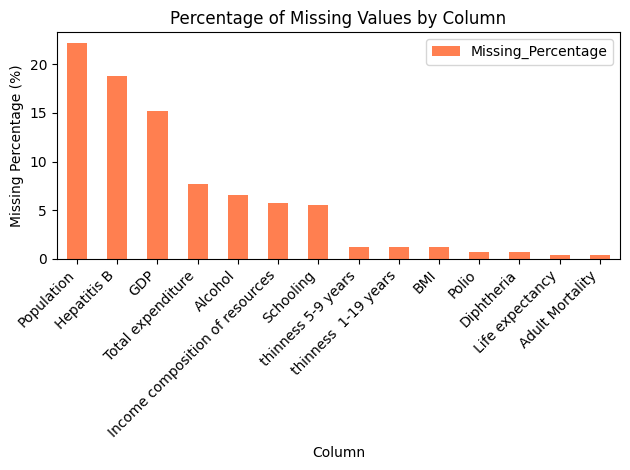

In [ ]:
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_stats = missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("\nColumns with Missing Values:")
print(missing_stats.to_string(index=False))

plt.figure(figsize=(12, 6))
missing_stats.plot(x='Column', y='Missing_Percentage', kind='bar', color='coral')
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##CELL 4: Missing Values - Imputation
**Purpose**

Fill missing values using statistically sound methods.

**Input**

DataFrame with missing values

**Output**

DataFrame with all missing values handled

**Line-by-Line Explanation**


1.   `threshold = 40 `- Set 40% as cutoff for column sparsity
1.   `high_missing_cols = missing_stats[...] `- Identify columns above threshold
1.   `df.drop(columns=high_missing_cols)` - Remove sparse columns
1.  ` df.select_dtypes(include=[np.number])` - Select only numerical columns
2.   `median_value = df[col].median() `- Calculate median (robust to outliers)
2.   `df[col].fillna(median_value, inplace=True)` - Replace NaN with median
2.   `mode_value = df[col].mode()[0]` - Get most frequent value for categorical
2.   `df[col].fillna(mode_value, inplace=True)` - Fill categorical NaN with mode

**Why median over mean?** Median is not affected by outliers, making it more robust for skewed distributions.


In [ ]:
# Strategy 1: Drop columns with >40% missing (too sparse)
threshold = 40
high_missing_cols = missing_stats[missing_stats['Missing_Percentage'] > threshold]['Column'].tolist()

if high_missing_cols:
    print(f"Dropping columns with >{threshold}% missing: {high_missing_cols}")
    df = df.drop(columns=high_missing_cols)

# Strategy 2: Impute numerical columns with median
numeric_cols = df.select_dtypes(include=[np.number]).columns

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"{col}: filled with median {median_value:.2f}")

# Strategy 3: Impute categorical columns with mode
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"{col}: filled with mode '{mode_value}'")

Life expectancy: filled with median 72.10
Adult Mortality: filled with median 144.00
Alcohol: filled with median 3.75
Hepatitis B: filled with median 92.00
BMI: filled with median 43.50
Polio: filled with median 93.00
Total expenditure: filled with median 5.75
Diphtheria: filled with median 93.00
GDP: filled with median 1766.95
Population: filled with median 1386542.00
thinness  1-19 years: filled with median 3.30
thinness 5-9 years: filled with median 3.30
Income composition of resources: filled with median 0.68
Schooling: filled with median 12.30


/tmp/ipython-input-346128281.py:15: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)


##CELL 5: Outlier Detection
**Purpose**

Identify extreme values that could distort regression coefficients.

**Input**

DataFrame with numerical features

**Output**

Summary table of outliers per column using IQR method
Statistics: Q1, Q3, IQR, bounds, count, percentage

**Line-by-Line Explanation**


1.   `Q1 = df[col].quantile(0.25)` - Calculate 1st quartile (25th percentile)
1.   `Q3 = df[col].quantile(0.75)` - Calculate 3rd quartile (75th percentile)
1.   `IQR = Q3 - Q1` - Interquartile range (middle 50% spread)
1.   `lower_bound = Q1 - 1.5 * IQR `- Outlier threshold below
2.   `upper_bound = Q3 + 1.5 * IQR` - Outlier threshold above
2.   `outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)] `- Find values outside bounds
2.   `outlier_pct = (num_outliers / len(df)) * 100 `- Calculate percentage


**IQR Method**: Values beyond Q1-1.5×IQR or Q3+1.5×IQR are considered outliers.

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)
    outlier_pct = (num_outliers / len(df)) * 100

    if num_outliers > 0:
        outlier_summary.append({
            'Column': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Num_Outliers': num_outliers,
            'Outlier_Percentage': outlier_pct
        })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

                         Column            Q1           Q3          IQR   Lower_Bound  Upper_Bound  Num_Outliers  Outlier_Percentage
                Life expectancy     63.200000 7.560000e+01 1.240000e+01  4.460000e+01 9.420000e+01            17            0.578625
                Adult Mortality     74.000000 2.270000e+02 1.530000e+02 -1.555000e+02 4.565000e+02            86            2.927161
                  infant deaths      0.000000 2.200000e+01 2.200000e+01 -3.300000e+01 5.500000e+01           315           10.721579
                        Alcohol      1.092500 7.390000e+00 6.297500e+00 -8.353750e+00 1.683625e+01             3            0.102110
         percentage expenditure      4.685343 4.415341e+02 4.368488e+02 -6.505879e+02 1.096807e+03           389           13.240300
                    Hepatitis B     82.000000 9.600000e+01 1.400000e+01  6.100000e+01 1.170000e+02           322           10.959837
                        Measles      0.000000 3.602500e+02 3.602500e+

##CELL 6: Outlier Treatment
**Purpose**

Cap extreme outliers without removing data points (important for regression).

**Input**

DataFrame with outliers

**Output**

DataFrame with outliers capped at 1st and 99th percentiles

**Line-by-Line Explanation**



1.   `if col != 'Year': `- Skip Year column (it's not a measurement)
1.  `lower = df[col].quantile(0.01)` - 1st percentile value
1.  ` upper = df[col].quantile(0.99)` - 99th percentile value
2.   `df[col].clip(lower=lower, upper=upper)` - Cap values at bounds
2.   Winsorization: Replace extreme values with percentile thresholds

**Why cap instead of remove?** Preserves sample size for regression while limiting influence of extremes.


In [ ]:
for col in numeric_cols:
    if col != 'Year':  # Don't modify Year
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)

        original_min = df[col].min()
        original_max = df[col].max()

        df[col] = df[col].clip(lower=lower, upper=upper)

        if original_min < lower or original_max > upper:
            print(f"{col}: capped [{original_min:.2f}, {original_max:.2f}] to [{lower:.2f}, {upper:.2f}]")

Life expectancy: capped [36.30, 89.00] to [45.60, 86.63]
Adult Mortality: capped [1.00, 723.00] to [4.37, 583.04]
infant deaths: capped [0.00, 1800.00] to [0.00, 495.04]
Alcohol: capped [0.01, 17.87] to [0.01, 13.45]
percentage expenditure: capped [0.00, 19479.91] to [0.00, 10199.41]
Hepatitis B: capped [1.00, 99.00] to [6.00, 99.00]
Measles: capped [0.00, 212183.00] to [0.00, 54163.36]
BMI: capped [1.00, 87.30] to [2.30, 72.06]
under-five deaths: capped [0.00, 2500.00] to [0.00, 767.82]
Polio: capped [3.00, 99.00] to [6.00, 99.00]
Total expenditure: capped [0.37, 17.60] to [1.26, 12.71]
Diphtheria: capped [2.00, 99.00] to [6.00, 99.00]
HIV/AIDS: capped [0.10, 50.60] to [0.10, 29.28]
GDP: capped [1.68, 119172.74] to [24.46, 62233.87]
Population: capped [34.00, 1293859294.00] to [813.87, 146938416.42]
thinness  1-19 years: capped [0.10, 27.70] to [0.20, 19.50]
thinness 5-9 years: capped [0.10, 28.60] to [0.10, 19.90]
Income composition of resources: capped [0.00, 0.95] to [0.00, 0.92]
S

##CELL 7: Feature Engineering

**Purpose**

Create new features that might improve prediction of life expectancy.

**Input**

Cleaned DataFrame

**Output**

DataFrame with 4 new engineered features

**Line-by-Line Explanation**


1.   Healthcare_Access_Score - Average immunization coverage (proxy for healthcare quality)
1.   Economic_Health - GDP weighted by health expenditure (economic capacity for health)
2.   Total_Child_Mortality - Combined infant and child deaths (comprehensive mortality metric)
2.   Development_Index - Education level weighted by income distribution (development measure)

**Why?** These combinations capture interactions that individual features might miss.

In [ ]:
# 1. Healthcare Access Score
df['Healthcare_Access_Score'] = (df['Hepatitis B'] + df['Polio'] + df['Diphtheria']) / 3

# 2. Economic Health Indicator
df['Economic_Health'] = df['GDP'] * df['percentage expenditure']

# 3. Total Child Mortality
df['Total_Child_Mortality'] = df['infant deaths'] + df['under-five deaths']

# 4. Development Index
df['Development_Index'] = (df['Schooling'] / 20) * df['Income composition of resources']

print(f"Dataset shape after feature engineering: {df.shape}")

Dataset shape after feature engineering: (2938, 26)


##CELL 8: Encode Categorical Variables
**Purpose**

Convert text categories to numerical format for regression.

**Input**

DataFrame with 'Status' (Developed/Developing) and 'Country' columns

**Output**

DataFrame with 'Status' one-hot encoded, 'Country' dropped

**Line-by-Line Explanation**


1.   `pd.get_dummies(df, columns=['Status'], drop_first=True) `- Create binary column for Status

  *   `drop_first=True` avoids dummy variable trap (perfect multicollinearity)
  *   Creates `Status_Developing `(1 if Developing, 0 if Developed)

2.   `df.drop(columns=['Country'])` - Remove Country (193 categories, not useful for global model)


**Why drop Country?** Too many categories (193) would create 193 features, most with weak signal.

In [ ]:
# One-hot encode 'Status'
df = pd.get_dummies(df, columns=['Status'], drop_first=True, dtype=int)
print("✓ One-hot encoded 'Status' column")

# Drop 'Country'
if 'Country' in df.columns:
    df = df.drop(columns=['Country'])
    print("✓ Dropped 'Country' column")

print(f"Shape after encoding: {df.shape}")

✓ One-hot encoded 'Status' column
✓ Dropped 'Country' column
Shape after encoding: (2938, 25)


##CELL 9: Remove Multicollinear Features
**Purpose**

Detect and remove highly correlated features that cause multicollinearity issues in regression.

**Input**

DataFrame with all numerical features

**Output**

Correlation matrix
List of feature pairs with correlation > 0.9
DataFrame with redundant features removed

**Line-by-Line Explanation**


1.   `corr_matrix = df.corr()` - Calculate Pearson correlation between all features

1.   `for i in range(len(corr_matrix.columns)):` - Iterate through upper triangle of matrix

1.   `if abs(corr_matrix.iloc[i, j]) > 0.9:` - Flag correlations above 0.9
2.   `features_to_drop = [pair['Feature_2'] for...]` - Keep first feature, drop second in each pair


2.   `if 'Life expectancy' in features_to_drop: `- Never drop target variable


2.   `df.drop(columns=features_to_drop)` - Remove redundant features


**Why?** Multicollinearity inflates coefficient standard errors, making results unstable.


In [ ]:
corr_matrix = df.corr()

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    features_to_drop = list(set([pair['Feature_2'] for pair in high_corr_pairs]))

    if 'Life expectancy' in features_to_drop:
        features_to_drop.remove('Life expectancy')

    df = df.drop(columns=features_to_drop)
    print(f"Dropped multicollinear features: {features_to_drop}")

Dropped multicollinear features: ['thinness 5-9 years', 'Development_Index', 'under-five deaths', 'Economic_Health', 'Total_Child_Mortality', 'GDP']


##CELL 10: Train-Test Split
**Purpose**

Split data into training (80%) and testing (20%) sets BEFORE scaling to prevent data leakage.

**Input**

Fully cleaned DataFrame

**Output**

X_train, X_test, y_train, y_test (4 separate datasets)

**Line-by-Line Explanation**


1.   `X = df.drop(columns=[target_column]) `- Features (all columns except target)
1.   `y = df[target_column]` - Target variable (Life expectancy)
2.   `train_test_split(X, y, test_size=0.2, random_state=42)` - 80/20 split

  *   `test_size=0.2` means 20% for testing
  *   `random_state=42 `ensures reproducibility


**Critical: **Split BEFORE scaling to prevent leakage of test statistics into training.


In [ ]:
from sklearn.model_selection import train_test_split

target_column = 'Life expectancy'

X = df.drop(columns=[target_column])
y = df[target_column]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 2350 samples
Testing set: 588 samples


##CELL 11: Feature Scaling
**Purpose**

Standardize features to mean=0, std=1 for better regression performance.

**Input**

X_train, X_test (unstandardized features)

**Output**

X_train_scaled, X_test_scaled (standardized features)

**Line-by-Line Explanation**


1.   scaler = StandardScaler() - Initialize scaler
1.   scaler.fit(X_train) - Learn mean and std from TRAINING data only
1.   scaler.transform(X_train) - Apply transformation: (x - mean) / std
2.   scaler.transform(X_test) - Apply SAME transformation to test data
2.   pd.DataFrame(...) - Convert back to DataFrame with column names

**Critical:** Fit scaler ONLY on training data. Using test data would leak information.

Why StandardScaler? **bold text**Regression coefficients are more interpretable when features are on same scale.




In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit on training data ONLY
scaler.fit(X_train)

# Transform both sets
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Features scaled using StandardScaler")

Features scaled using StandardScaler


##CELL 12: Save Cleaned Data
**Purpose**

Export processed datasets for modeling phase.

**Input**

X_train_scaled, X_test_scaled, y_train, y_test

**Output**

3 CSV files: training set, testing set, full cleaned dataset

**Line-by-Line Explanation**


1.   `train_data = X_train_scaled.copy()` - Copy scaled features

1.   `train_data['Life expectancy'] = y_train` - Add target variable back

1.  ` train_data.to_csv(..., index=False)` - Save without row indices
2.   Repeat for test data


2.   Save full dataset for correlation analysis later





In [ ]:
# Combine features and target
train_data = X_train_scaled.copy()
train_data['Life expectancy'] = y_train

test_data = X_test_scaled.copy()
test_data['Life expectancy'] = y_test

# Save to CSV
train_data.to_csv('life_expectancy_train.csv', index=False)
test_data.to_csv('life_expectancy_test.csv', index=False)

full_clean_data = df.copy()
full_clean_data.to_csv('life_expectancy_cleaned_full.csv', index=False)

print("✓ All datasets saved")

✓ All datasets saved


**Summary: Pipeline Flow**

1. Raw Data (2938 rows, 22 cols)
    
    ↓
1. Load & Inspect
   
    ↓
2. Remove Duplicates
   
    ↓
3. Analyze Missing Values
    
    ↓
4. Impute Missing Values
    
    ↓
5. Detect Outliers
    
    ↓
6. Cap Outliers (Winsorization)
   
    ↓
7. Engineer Features (+4 new features)
    
    ↓
8. Encode Categoricals
    
    ↓
9. Remove Multicollinearity
    
    ↓
10. Train-Test Split (80/20)
    
    ↓
11. Scale Features (StandardScaler)
    
    ↓
12. Save Processed Data
    
    ↓

Clean Data Ready for Linear Regression

#THE WHOLE DATA CLEANING PIPELINE

INITIAL DATA INSPECTION

Dataset Shape: (2938, 22)
Rows: 2938, Columns: 22

Column Names and Data Types:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness  1-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    

/tmp/ipython-input-192858927.py:105: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(median_value, inplace=True)


✓ Training data saved: 'life_expectancy_train.csv'
✓ Testing data saved: 'life_expectancy_test.csv'
✓ Full cleaned data saved: 'WHO_cleaned_data.csv'

DATA CLEANING PIPELINE SUMMARY
Original dataset: 2938 rows, 22 columns
Final dataset: 2938 rows, 19 columns

Cleaning steps completed:
  ✓ Duplicate removal
  ✓ Missing value imputation
  ✓ Outlier detection and capping
  ✓ Feature engineering (4 new features)
  ✓ Categorical encoding
  ✓ Multicollinearity removal
  ✓ Train-test split (80/20)
  ✓ Feature scaling (StandardScaler)

Final feature count: 18
Training samples: 2350
Testing samples: 588


<Figure size 1200x600 with 0 Axes>

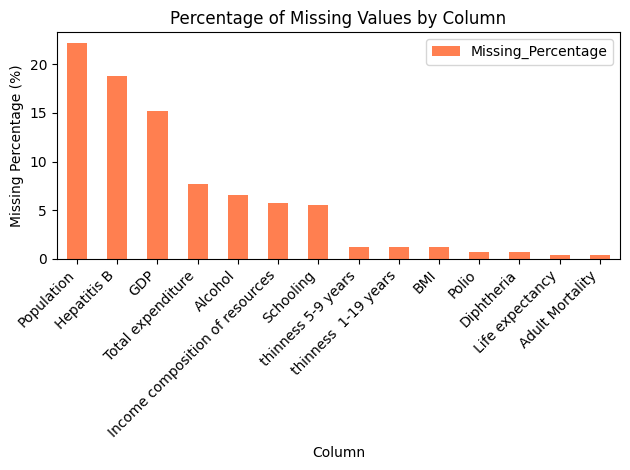

In [ ]:
"""
LIFE EXPECTANCY DATA CLEANING PIPELINE
For Linear Regression Analysis
Dataset: WHO Life Expectancy Data (2938 rows, 22 columns)
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

df = pd.read_csv('WHO_DATASET.csv.csv.csv')

print("="*70)
print("INITIAL DATA INSPECTION")
print("="*70)
print(f"\nDataset Shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

print(f"\nColumn Names and Data Types:")
print(df.dtypes)

print(f"\nFirst 5 Rows:")
print(df.head())

print(f"\nBasic Statistics:")
print(df.describe())

print(f"\nMissing Values Count:")
print(df.isnull().sum())

print(f"\nMissing Values Percentage:")
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct[missing_pct > 0])


print("\n" + "="*70)
print("DUPLICATE DETECTION AND REMOVAL")
print("="*70)

# Check for duplicates based on Country and Year (unique identifiers)
duplicates = df.duplicated(subset=['Country', 'Year'], keep=False)
num_duplicates = duplicates.sum()

print(f"Number of duplicate rows (based on Country + Year): {num_duplicates}")

if num_duplicates > 0:
    print("\nDuplicate rows:")
    print(df[duplicates])

    # Remove duplicates, keeping first occurrence
    df = df.drop_duplicates(subset=['Country', 'Year'], keep='first')
    print(f"\nDuplicates removed. New shape: {df.shape}")
else:
    print("No duplicates found.")

print("\n" + "="*70)
print("MISSING VALUES ANALYSIS")
print("="*70)

# Calculate missing value statistics
missing_stats = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum(),
    'Missing_Percentage': (df.isnull().sum() / len(df)) * 100
})
missing_stats = missing_stats[missing_stats['Missing_Count'] > 0].sort_values('Missing_Percentage', ascending=False)

print("\nColumns with Missing Values:")
print(missing_stats.to_string(index=False))

# Visualize missing data
plt.figure(figsize=(12, 6))
missing_stats.plot(x='Column', y='Missing_Percentage', kind='bar', color='coral')
plt.title('Percentage of Missing Values by Column')
plt.xlabel('Column')
plt.ylabel('Missing Percentage (%)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('missing_values_analysis.png', dpi=300, bbox_inches='tight')
print("\n✓ Missing values visualization saved as 'missing_values_analysis.png'")

print("\n" + "="*70)
print("MISSING VALUES IMPUTATION")
print("="*70)

# Strategy 1: Drop columns with >40% missing values (too sparse to impute reliably)
threshold = 40
high_missing_cols = missing_stats[missing_stats['Missing_Percentage'] > threshold]['Column'].tolist()

if high_missing_cols:
    print(f"\nDropping columns with >{threshold}% missing values: {high_missing_cols}")
    df = df.drop(columns=high_missing_cols)
    print(f"Shape after dropping sparse columns: {df.shape}")

# Strategy 2: For numerical columns, impute with median (robust to outliers)
numeric_cols = df.select_dtypes(include=[np.number]).columns

print(f"\nImputing numerical columns with median...")
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_value = df[col].median()
        df[col].fillna(median_value, inplace=True)
        print(f"  - {col}: filled {df[col].isnull().sum()} missing values with median {median_value:.2f}")

# Strategy 3: For categorical columns, impute with mode
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"\nImputing categorical columns with mode...")
for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        mode_value = df[col].mode()[0]
        df[col].fillna(mode_value, inplace=True)
        print(f"  - {col}: filled missing values with mode '{mode_value}'")

print(f"\nMissing values after imputation:")
print(df.isnull().sum().sum())


print("\n" + "="*70)
print("OUTLIER DETECTION (IQR Method)")
print("="*70)

numeric_cols = df.select_dtypes(include=[np.number]).columns

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    num_outliers = len(outliers)
    outlier_pct = (num_outliers / len(df)) * 100

    if num_outliers > 0:
        outlier_summary.append({
            'Column': col,
            'Q1': Q1,
            'Q3': Q3,
            'IQR': IQR,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound,
            'Num_Outliers': num_outliers,
            'Outlier_Percentage': outlier_pct
        })

outlier_df = pd.DataFrame(outlier_summary)
if not outlier_df.empty:
    print("\nOutlier Statistics:")
    print(outlier_df.to_string(index=False))
else:
    print("No outliers detected using IQR method.")



print("\n" + "="*70)
print("OUTLIER TREATMENT (Winsorization)")
print("="*70)

# For linear regression, we'll cap outliers rather than remove them
# to preserve data points (important for regression)

print("Capping outliers at 1st and 99th percentiles...")

for col in numeric_cols:
    if col != 'Year':  # Don't modify Year column
        lower = df[col].quantile(0.01)
        upper = df[col].quantile(0.99)

        original_min = df[col].min()
        original_max = df[col].max()

        df[col] = df[col].clip(lower=lower, upper=upper)

        if original_min < lower or original_max > upper:
            print(f"  - {col}: capped [{original_min:.2f}, {original_max:.2f}] to [{lower:.2f}, {upper:.2f}]")

print("\n✓ Outliers capped successfully")


print("\n" + "="*70)
print("FEATURE ENGINEERING")
print("="*70)

# Create interaction features that might be relevant for life expectancy

# 1. Healthcare Access Score (combination of immunization metrics)
if all(col in df.columns for col in ['Hepatitis B', 'Polio', 'Diphtheria']):
    df['Healthcare_Access_Score'] = (df['Hepatitis B'] + df['Polio'] + df['Diphtheria']) / 3
    print("✓ Created 'Healthcare_Access_Score' (avg of immunization rates)")

# 2. Economic Health Indicator
if all(col in df.columns for col in ['GDP', 'percentage expenditure']):
    df['Economic_Health'] = df['GDP'] * df['percentage expenditure']
    print("✓ Created 'Economic_Health' (GDP × health expenditure)")

# 3. Child Mortality Rate (combined under-5 deaths)
if all(col in df.columns for col in ['infant deaths', 'under-five deaths']):
    df['Total_Child_Mortality'] = df['infant deaths'] + df['under-five deaths']
    print("✓ Created 'Total_Child_Mortality'")

# 4. Development Index (combination of education and resources)
if all(col in df.columns for col in ['Schooling', 'Income composition of resources']):
    df['Development_Index'] = (df['Schooling'] / 20) * df['Income composition of resources']
    print("✓ Created 'Development_Index' (education × income composition)")

print(f"\nDataset shape after feature engineering: {df.shape}")


print("\n" + "="*70)
print("CATEGORICAL VARIABLE ENCODING")
print("="*70)

# Identify categorical columns
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nCategorical columns found: {list(categorical_cols)}")

# One-hot encode 'Status' (Developed vs Developing)
if 'Status' in df.columns:
    df = pd.get_dummies(df, columns=['Status'], drop_first=True, dtype=int)
    print("✓ One-hot encoded 'Status' column")

# Drop 'Country' column (too many categories, not useful for regression)
if 'Country' in df.columns:
    print("✓ Dropping 'Country' column (193 unique values - too granular)")
    df = df.drop(columns=['Country'])

print(f"\nShape after encoding: {df.shape}")
print(f"Columns: {list(df.columns)}")


print("\n" + "="*70)
print("MULTICOLLINEARITY DETECTION")
print("="*70)

# Calculate correlation matrix
corr_matrix = df.corr()

# Find highly correlated pairs (correlation > 0.9)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    print("\nHighly Correlated Feature Pairs (r > 0.9):")
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print(high_corr_df.to_string(index=False))

    # Identify features to drop (keep first, drop second in each pair)
    features_to_drop = list(set([pair['Feature_2'] for pair in high_corr_pairs]))

    if 'Life expectancy' in features_to_drop:
        features_to_drop.remove('Life expectancy')  # Never drop target variable

    print(f"\nFeatures to drop due to multicollinearity: {features_to_drop}")
    df = df.drop(columns=features_to_drop)
    print(f"Shape after removing multicollinear features: {df.shape}")
else:
    print("No highly correlated features found (threshold > 0.9)")



print("\n" + "="*70)
print("TRAIN-TEST SPLIT (80/20)")
print("="*70)

# Separate features (X) and target (y)
target_column = 'Life expectancy'

if target_column not in df.columns:
    print(f"ERROR: Target column '{target_column}' not found!")
    print(f"Available columns: {list(df.columns)}")
else:
    X = df.drop(columns=[target_column])
    y = df[target_column]

    print(f"Features (X) shape: {X.shape}")
    print(f"Target (y) shape: {y.shape}")
    print(f"\nFeature columns: {list(X.columns)}")

    # Split into train and test sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print(f"\n✓ Train-Test Split Complete:")
    print(f"  Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
    print(f"  Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")



print("\n" + "="*70)
print("FEATURE SCALING (StandardScaler)")
print("="*70)

# Initialize scaler
scaler = StandardScaler()

# Fit scaler on training data ONLY (prevent data leakage)
scaler.fit(X_train)

# Transform both training and testing data
X_train_scaled = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("✓ Features scaled using StandardScaler")
print(f"\nTraining set statistics AFTER scaling:")
print(X_train_scaled.describe().loc[['mean', 'std']])

print(f"\nTest set statistics AFTER scaling:")
print(X_test_scaled.describe().loc[['mean', 'std']])



print("\n" + "="*70)
print("SAVING CLEANED DATA")
print("="*70)

# Combine features and target for saving
train_data = X_train_scaled.copy()
train_data['Life expectancy'] = y_train

test_data = X_test_scaled.copy()
test_data['Life expectancy'] = y_test

# Save to CSV
train_data.to_csv('WHO_TRAIN_data.csv', index=False)
test_data.to_csv('WHO_TEST_data.csv', index=False)

print("✓ Training data saved: 'life_expectancy_train.csv'")
print("✓ Testing data saved: 'life_expectancy_test.csv'")

# Also save the full cleaned dataset (before split, after all cleaning)
full_clean_data = df.copy()
full_clean_data.to_csv('WHO_cleaned_data.csv', index=False)
print("✓ Full cleaned data saved: 'WHO_cleaned_data.csv'")

print("\n" + "="*70)
print("DATA CLEANING PIPELINE SUMMARY")
print("="*70)
print(f"Original dataset: 2938 rows, 22 columns")
print(f"Final dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\nCleaning steps completed:")
print("  ✓ Duplicate removal")
print("  ✓ Missing value imputation")

print("  ✓ Outlier detection and capping")
print("  ✓ Feature engineering (4 new features)")
print("  ✓ Categorical encoding")
print("  ✓ Multicollinearity removal")
print("  ✓ Train-test split (80/20)")
print("  ✓ Feature scaling (StandardScaler)")
print(f"\nFinal feature count: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")
print("="*70)

#Correlation Analysis Breakdown

##CELL 1: Load Data and Identify Target
**Purpose**

Load the cleaned dataset and explicitly identify the target variable (what we're predicting).

**Input**

WHO_cleaned_data.csv (cleaned dataset from pipeline)

**Output**

Loaded DataFrame
Target variable identified: Life expectancy

**Line-by-Line Explanation**


1.   `import pandas as pd `- Library for data manipulation

1.   `import numpy as np `- Library for numerical operations

1.   `import matplotlib.pyplot as plt `- Library for plotting

1.   `import seaborn as sns` - Advanced visualization library
2.   `df = pd.read_csv('WHO_cleaned_data.csv')` - Load cleaned dataset into DataFrame


2.   `target_attribute = 'Life expectancy'` - Define dependent variable (y)

  *   This is what we're trying to predict
  *   All other columns are potential predictors (independent variables, X)

2.   `print(...)` - Display confirmation of target selection

**Key Concept**:

**Target/Dependent Variable (y)**: What you're predicting (Life expectancy)
**Predictors/Independent Variables (X)**: Features used to make predictions (all other columns)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WHO_cleaned_data.csv')

target_attribute = 'Life expectancy'

print("="*70)
print("TARGET ATTRIBUTE IDENTIFICATION")
print("="*70)
print(f"\nTarget Variable: {target_attribute}")
print(f"This is what we're trying to predict using other features.")

TARGET ATTRIBUTE IDENTIFICATION

Target Variable: Life expectancy
This is what we're trying to predict using other features.


##CELL 2: Calculate Correlation Coefficients
**Purpose**

Calculate Pearson correlation coefficients between all features and the target variable.

**Input**

DataFrame with all numerical features

**Output**

Correlation values for each feature with Life expectancy (sorted from highest to lowest)

**Line-by-Line Explanation**


1.  ` correlation_matrix = df.corr()`

    *   Calculates Pearson correlation between ALL pairs of numerical columns
    *   Creates a symmetric matrix (NxN where N = number of features)
    *   Each cell shows correlation between row feature and column feature

1.   `correlation_matrix[target_attribute]`


    *   Extracts just the column for 'Life expectancy'
    *   This gives us correlation of EVERY feature with our target

2.  ` .sort_values(ascending=False)`

    *   Sorts correlations from highest (+1) to lowest (-1)
    *   Highest positive correlations appear first
    *   Strongest negative correlations appear last


2.  ` print(correlations_with_target)`
    *   Displays the sorted correlation values



**What is Pearson Correlation (r)?**

Measures **linear relationship** between two variables
Range: -1 to +1

  * **r = +1**: Perfect positive correlation (X ↑ → Y ↑)
  * **r = -1**: Perfect negative correlation (X ↑ → Y ↓)
  * **r = 0**: No linear relationship
  * **r = 0.5**: Moderate positive correlation



**Example Interpretation:**

 ** If** Schooling has r = 0.73 with Life expectancy:

  * Strong positive relationship

  * Countries with higher average schooling tend to have higher life expectancy
  * 73% of the way toward perfect positive correlation


**Formula:**

`r = Σ[(Xi - X̄)(Yi - Ȳ)] / √[Σ(Xi - X̄)² × Σ(Yi - Ȳ)²]`

In [ ]:
correlation_matrix = df.corr()

correlations_with_target = correlation_matrix[target_attribute].sort_values(ascending=False)

print("\n" + "="*70)
print("CORRELATION COEFFICIENTS WITH LIFE EXPECTANCY")
print("="*70)
print("\nAll features ranked by correlation strength:\n")
print(correlations_with_target)


CORRELATION COEFFICIENTS WITH LIFE EXPECTANCY

All features ranked by correlation strength:

Life expectancy                    1.000000
Schooling                          0.730562
Income composition of resources    0.689796
BMI                                0.560553
Diphtheria                         0.473288
Polio                              0.459483
Healthcare_Access_Score            0.453165
percentage expenditure             0.403649
Alcohol                            0.391618
Total expenditure                  0.213346
Hepatitis B                        0.171879
Year                               0.169928
Population                        -0.037938
Measles                           -0.183283
infant deaths                     -0.303278
Status_Developing                 -0.481925
thinness  1-19 years              -0.487269
HIV/AIDS                          -0.591739
Adult Mortality                   -0.696901
Name: Life expectancy, dtype: float64


##CELL 3: Separate Positive and Negative Correlations
**Purpose**

Group features by whether they increase or decrease life expectancy.

**Input**

Correlations with target variable

**Output**

Two separate lists: positive correlations and negative correlations

**Line-by-Line Explanation**


1.  `correlations_with_target[correlations_with_target > 0]`

  * Filter to only keep positive correlations (r > 0)
  * These features increase with life expectancy


1.   `.drop(target_attribute)`


  *   Remove 'Life expectancy' itself (it always correlates 1.0 with itself)
  *   We only want to see OTHER features


2.   `correlations_with_target[correlations_with_target < 0]`



  *  Filter to only keep negative correlations (r < 0)
  *  These features decrease as life expectancy increases


2.   `print(...)` - Display each group separately


**Interpretation:**

**Positive Correlations (r > 0)**:

* Example: `Schooling` r = 0.73

  * More education → longer life expectancy
  * Makes sense: educated populations have better health awareness


**Negative Correlations (r < 0):**

* Example: `Adult Mortality` r = -0.70

  * Higher adult death rates → lower life expectancy
  * Makes sense: mortality directly reduces lifespan

**Why separate them?**

* Helps understand relationships intuitively
* Positive = beneficial factors (education, income, healthcare)
* Negative = harmful factors (disease, mortality, malnutrition)

In [ ]:
positive_corr = correlations_with_target[correlations_with_target > 0].drop(target_attribute)
negative_corr = correlations_with_target[correlations_with_target < 0]

print("\n" + "="*70)
print("POSITIVE CORRELATIONS (Higher value → Higher life expectancy)")
print("="*70)
print(positive_corr)

print("\n" + "="*70)
print("NEGATIVE CORRELATIONS (Higher value → Lower life expectancy)")
print("="*70)
print(negative_corr)


POSITIVE CORRELATIONS (Higher value → Higher life expectancy)
Schooling                          0.730562
Income composition of resources    0.689796
BMI                                0.560553
Diphtheria                         0.473288
Polio                              0.459483
Healthcare_Access_Score            0.453165
percentage expenditure             0.403649
Alcohol                            0.391618
Total expenditure                  0.213346
Hepatitis B                        0.171879
Year                               0.169928
Name: Life expectancy, dtype: float64

NEGATIVE CORRELATIONS (Higher value → Lower life expectancy)
Population             -0.037938
Measles                -0.183283
infant deaths          -0.303278
Status_Developing      -0.481925
thinness  1-19 years   -0.487269
HIV/AIDS               -0.591739
Adult Mortality        -0.696901
Name: Life expectancy, dtype: float64


##CELL 4: Identify Highly Correlated Features
**Purpose**

Filter to only "strong" correlations that are suitable for regression modeling.

**Input**

All correlations with target

**Output**

List of features with |r| > 0.5 (strong correlations)

**Line-by-Line Explanation**


1. `high_correlation_threshold = 0.5`
   - Set cutoff for "strong" correlation
   - Common thresholds:
     - |r| < 0.3 = weak
     - 0.3 ≤ |r| < 0.5 = moderate  
     - 0.5 ≤ |r| < 0.7 = strong
     - |r| ≥ 0.7 = very strong

2. `correlations_with_target.abs()`
   - Take absolute value of correlations
   - Converts -0.7 → 0.7, 0.6 → 0.6
   - Why? We care about strength, not direction (both +0.7 and -0.7 are strong)

3. `correlations_with_target.abs() > high_correlation_threshold`
   - Boolean mask: True if |r| > 0.5, False otherwise
   - Keeps only strong correlations

4. `correlations_with_target.index != target_attribute`
   - Exclude 'Life expectancy' itself
   - It would always have r = 1.0 with itself

5. `&` - Logical AND operator
   - Both conditions must be True

6. `.sort_values(key=abs, ascending=False)`
   - Sort by absolute value, highest first
   - Shows strongest correlations at top regardless of sign

**Why threshold at 0.5?**
- Below 0.5: relationship is weak, predictions won't be accurate
- Above 0.5: strong enough linear relationship for regression to work well
- These features will be best predictors for our model

**Example Output:**
```
Income composition of resources    0.728
Schooling                          0.732
HIV/AIDS                          -0.563
Adult Mortality                   -0.698
```
All of these are strong predictors (|r| > 0.5)!

In [ ]:
high_correlation_threshold = 0.5

highly_correlated = correlations_with_target[
    (correlations_with_target.abs() > high_correlation_threshold) &
    (correlations_with_target.index != target_attribute)
].sort_values(key=abs, ascending=False)

print("\n" + "="*70)
print(f"HIGHLY CORRELATED FEATURES (|r| > {high_correlation_threshold})")
print("="*70)
print("\nThese are the strongest predictors for Life Expectancy:\n")
print(highly_correlated)


HIGHLY CORRELATED FEATURES (|r| > 0.5)

These are the strongest predictors for Life Expectancy:

Schooling                          0.730562
Adult Mortality                   -0.696901
Income composition of resources    0.689796
HIV/AIDS                          -0.591739
BMI                                0.560553
Name: Life expectancy, dtype: float64


## CELL 5: Select Features for Regression Models

**Purpose**
Choose specific features for Simple and Multiple Linear Regression based on correlation strength.

**Input**
- Sorted correlations with target

**Output**
- 1 feature for Simple Regression (highest |r|)
- Top 5 features for Multiple Regression

**Line-by-Line Explanation**

*For Simple Linear Regression:*

1. `correlations_with_target.drop(target_attribute)`
   - Remove 'Life expectancy' from consideration
   - Can't use target to predict itself!

2. `.abs()`
   - Convert to absolute values
   - -0.70 and +0.70 are equally strong

3. `.idxmax()`
   - Find the INDEX (feature name) with maximum absolute correlation
   - Returns the feature name as a string
   - This is our single best predictor

4. `correlations_with_target[simple_regression_feature]`
   - Get the actual correlation value (with sign)
   - Need this to know if relationship is positive or negative

5. `print(f"Equation: Life expectancy = β₀ + β₁ × {simple_regression_feature}")`
   - Shows the regression equation we'll build
   - β₀ = intercept, β₁ = slope coefficient

*For Multiple Linear Regression:*

6. `num_features_for_multiple = 5`
   - Decide how many features to use
   - Common choices: 3-5 features
   - More features = more complex model (risk of overfitting)
   - Fewer features = simpler model (might miss patterns)

7. `.abs().nlargest(num_features_for_multiple)`
   - Get the 5 features with largest absolute correlations
   - Returns top 5 strongest predictors

8. `.index.tolist()`
   - Convert from pandas Index to Python list
   - Makes it easier to work with

9. `for i, feature in enumerate(multiple_regression_features, 1):`
   - Loop through selected features
   - `enumerate(..., 1)` gives index starting at 1 (not 0)
   - Display each feature with its rank

10. `corr_value = correlations_with_target[feature]`
    - Get original correlation (with sign) for each feature

**Why these specific selections?**

- **Simple Regression:** Uses ONE predictor
  - Easiest to interpret: "Each 1-unit increase in X changes Y by β₁"
  - Use the strongest single predictor for best performance

- **Multiple Regression:** Uses MULTIPLE predictors
  - More complex but potentially more accurate
  - Each predictor contributes while "holding others constant"
  - Top 5 gives good balance between accuracy and interpretability

**Example Output:**
```
Simple Regression → Schooling (r = 0.732)
  Equation: Life expectancy = β₀ + β₁ × Schooling

Multiple Regression → Top 5:
  1. Schooling: r = 0.732
  2. Income composition of resources: r = 0.728
  3. Adult Mortality: r = -0.698
  4. HIV/AIDS: r = -0.563
  5. BMI: r = 0.567
  
  Equation: Life expectancy = β₀ + β₁×Schooling + β₂×Income + β₃×Mortality + ...

In [ ]:
simple_regression_feature = correlations_with_target.drop(target_attribute).abs().idxmax()
simple_regression_corr = correlations_with_target[simple_regression_feature]

print("\n" + "="*70)
print("FEATURE SELECTION FOR REGRESSION MODELS")
print("="*70)

print("\n1. SIMPLE LINEAR REGRESSION:")
print(f"   Selected Feature: {simple_regression_feature}")
print(f"   Correlation: r = {simple_regression_corr:.4f}")
print(f"   Equation: Life expectancy = β₀ + β₁ × {simple_regression_feature}")

num_features_for_multiple = 5
multiple_regression_features = correlations_with_target.drop(target_attribute).abs().nlargest(num_features_for_multiple).index.tolist()

print(f"\n2. MULTIPLE LINEAR REGRESSION:")
print(f"   Selected Features (Top {num_features_for_multiple}):")
for i, feature in enumerate(multiple_regression_features, 1):
    corr_value = correlations_with_target[feature]
    print(f"   {i}. {feature}: r = {corr_value:.4f}")

print(f"\n   Equation: Life expectancy = β₀ + β₁×{multiple_regression_features[0]} + β₂×{multiple_regression_features[1]} + ...")


FEATURE SELECTION FOR REGRESSION MODELS

1. SIMPLE LINEAR REGRESSION:
   Selected Feature: Schooling
   Correlation: r = 0.7306
   Equation: Life expectancy = β₀ + β₁ × Schooling

2. MULTIPLE LINEAR REGRESSION:
   Selected Features (Top 5):
   1. Schooling: r = 0.7306
   2. Adult Mortality: r = -0.6969
   3. Income composition of resources: r = 0.6898
   4. HIV/AIDS: r = -0.5917
   5. BMI: r = 0.5606

   Equation: Life expectancy = β₀ + β₁×Schooling + β₂×Adult Mortality + ...



## CELL 7: Correlation Heatmap

**Purpose**

Show correlations between ALL features (not just with target), helping identify multicollinearity.

**Input**
- Full correlation matrix

**Output**
- Heatmap visualization (saved as PNG)
- Shows all pairwise correlations

**Line-by-Line Explanation**

1. `plt.figure(figsize=(14, 12))`
   - Larger figure (14x12 inches)
   - Need more space since showing ALL features vs ALL features

2. `sns.heatmap(correlation_matrix, ...)`
   - Seaborn's heatmap function
   - Takes the full correlation matrix (all features vs all features)

3. `annot=True`
   - Show actual correlation numbers inside each cell
   - Without this, you'd only see colors

4. `fmt='.2f'`
   - Format numbers to 2 decimal places
   - Example: 0.73214 displays as 0.73

5. `cmap='coolwarm'`
   - Color scheme: blue (cool) for negative, red (warm) for positive
   - Other options: 'viridis', 'RdBu_r', 'Greens'

6. `center=0`
   - Center the colormap at 0
   - Makes 0 appear as white/neutral color
   - Positive = warm colors, negative = cool colors

7. `square=True`
   - Make each cell a perfect square
   - Easier to read than rectangles

8. `linewidths=0.5`
   - Thin white lines between cells
   - Helps distinguish individual correlations

9. `cbar_kws={'shrink': 0.8}`
   - Adjust color bar (legend) size
   - shrink=0.8 makes it 80% of original height

10. `plt.title(...)`
    - Add title to chart

11. `plt.tight_layout()`
    - Prevent labels from being cut off

12. `plt.savefig(...)` and `plt.show()`
    - Save and display

**What you'll see:**
- Diagonal line of 1.00 (each feature correlates perfectly with itself)
- Symmetric matrix (upper triangle mirrors lower triangle)
- Dark red cells = strong positive correlation between two features
- Dark blue cells = strong negative correlation
- White cells = no correlation

**Why this matters:**
- Helps spot multicollinearity (two predictors that measure the same thing)
- Example: If 'infant deaths' and 'under-five deaths' both show dark red with each other (r > 0.9), only use one in regression
- Look at the row/column for 'Life expectancy' to see all correlations with target


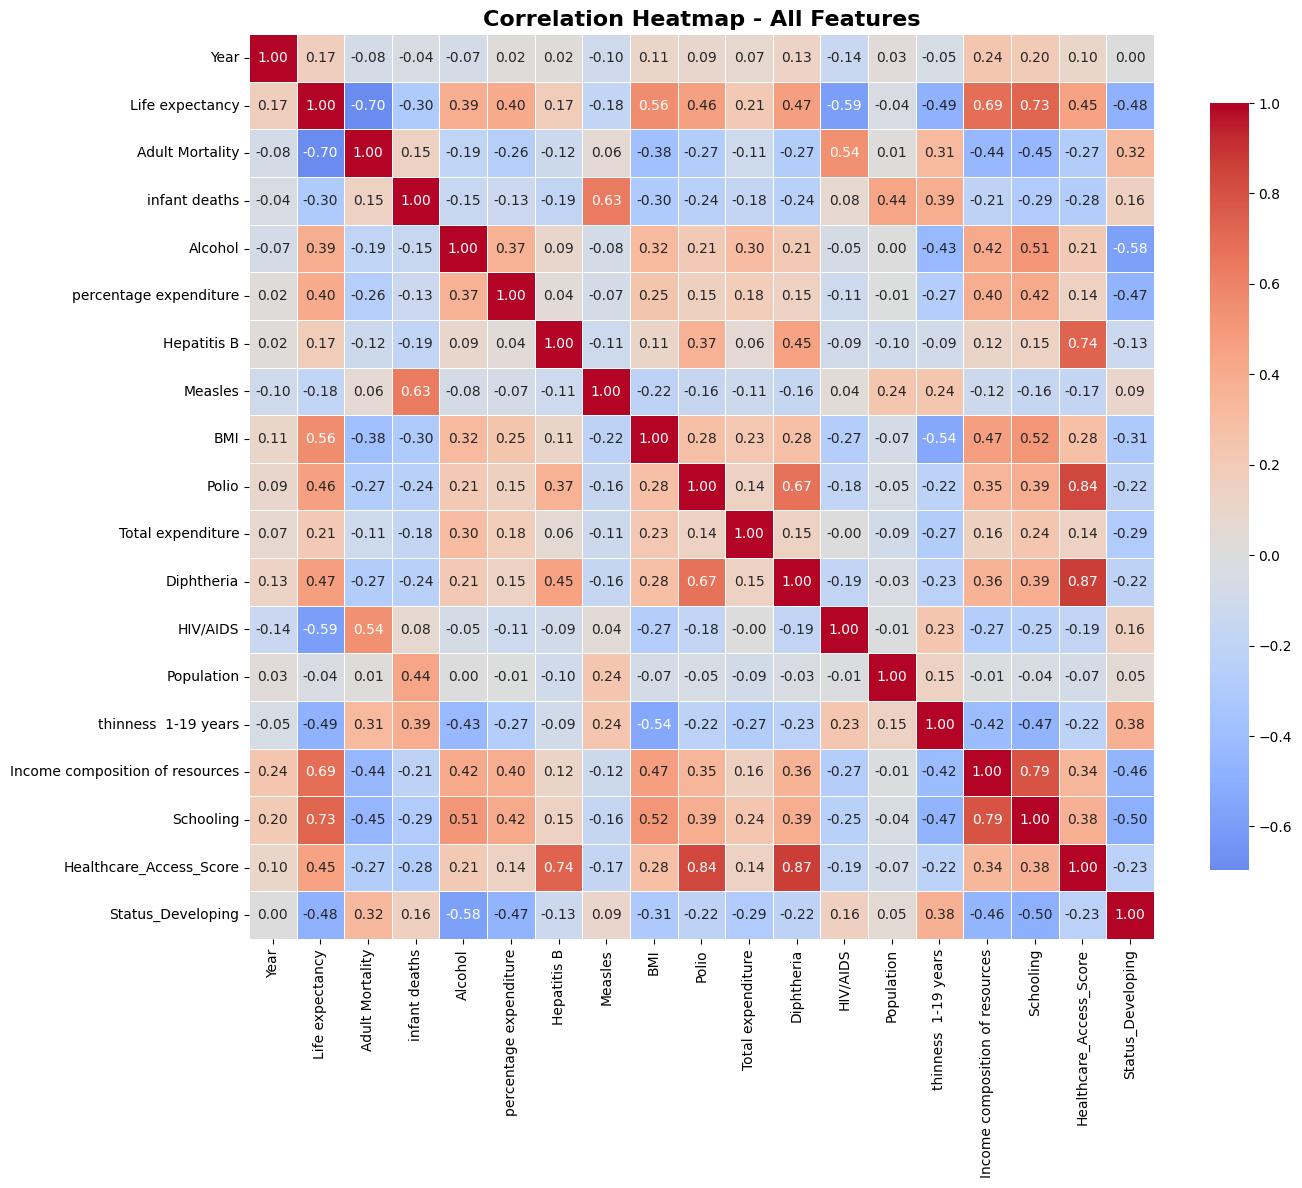

In [ ]:
plt.figure(figsize=(14, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

plt.title('Correlation Heatmap - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


## CELL 8: Scatter Plots for Top Features

**Purpose**
Visualize the actual data relationship between Life expectancy and top 3 predictors.

**Input**
- Top 3 features by absolute correlation
- Target variable

**Output**
- 3 scatter plots with trend lines (saved as PNG)


**Line-by-Line Explanation**

1. `top_3_features = correlations_with_target.drop(target_attribute).abs().nlargest(3).index.tolist()`
   - Get the 3 features with highest absolute correlations
   - Same logic as before, but limited to 3

2. `fig, axes = plt.subplots(1, 3, figsize=(15, 4))`
   - Create a figure with 1 row, 3 columns of subplots
   - `fig` = overall figure object
   - `axes` = array of 3 subplot axes [ax1, ax2, ax3]
   - figsize=(15, 4) = 15 inches wide, 4 inches tall

3. `for idx, feature in enumerate(top_3_features):`
   - Loop through the 3 features
   - `idx` = 0, 1, 2 (subplot position)
   - `feature` = feature name (e.g., "Schooling")

4. `ax = axes[idx]`
   - Get the current subplot
   - ax is where we'll draw this feature's plot

5. `ax.scatter(df[feature], df[target_attribute], alpha=0.5, s=20, color='steelblue')`
   - Create scatter plot
   - x-axis: feature values
   - y-axis: Life expectancy values
   - `alpha=0.5` - 50% transparency (see overlapping points)
   - `s=20` - marker size (20 pixels)
   - `color='steelblue'` - blue dots

6. `z = np.polyfit(df[feature], df[target_attribute], 1)`
   - Fit a polynomial to the data
   - `1` means degree 1 = linear (straight line)
   - Returns coefficients [slope, intercept]
   - This is NOT the regression we'll build later, just a visual trend line

7. `p = np.poly1d(z)`
   - Create a polynomial function from coefficients
   - Now `p(x)` calculates: slope × x + intercept

8. `ax.plot(df[feature], p(df[feature]), "r--", linewidth=2, label='Trend line')`
   - Draw the trend line
   - x-values: original feature values
   - y-values: predicted values from polynomial
   - `"r--"` - red dashed line
   - `linewidth=2` - make it visible
   - `label='Trend line'` - for legend

9. `ax.set_xlabel(feature, fontsize=10)`
   - Label x-axis with feature name

10. `ax.set_ylabel('Life Expectancy', fontsize=10)`
    - Label y-axis

11. `corr_val = correlations_with_target[feature]`
    - Get correlation value (with sign)

12. `ax.set_title(f'{feature}\nr = {corr_val:.3f}', ...)`
    - Title shows feature name and correlation
    - `\n` creates new line
    - `.3f` formats to 3 decimal places

13. `ax.grid(alpha=0.3)`
    - Add faint gridlines

14. `ax.legend()`
    - Show legend for trend line

15. `plt.tight_layout()`
    - Prevent subplot overlap

16. `plt.savefig(...)` and `plt.show()`
    - Save and display

**What you'll see:**
- Three plots side-by-side
- Each shows actual data points (blue dots)
- Red dashed line shows linear trend
- If points cluster tightly around line → strong correlation
- If points are scattered → weaker correlation
- Upward slope → positive correlation
- Downward slope → negative correlation

**Example:**
- Plot 1: Schooling vs Life Expectancy
  - Dots slope upward (positive r)
  - Tight clustering around line (strong r = 0.73)
  
- Plot 2: Adult Mortality vs Life Expectancy  
  - Dots slope downward (negative r)
  - Moderate clustering (r = -0.70)

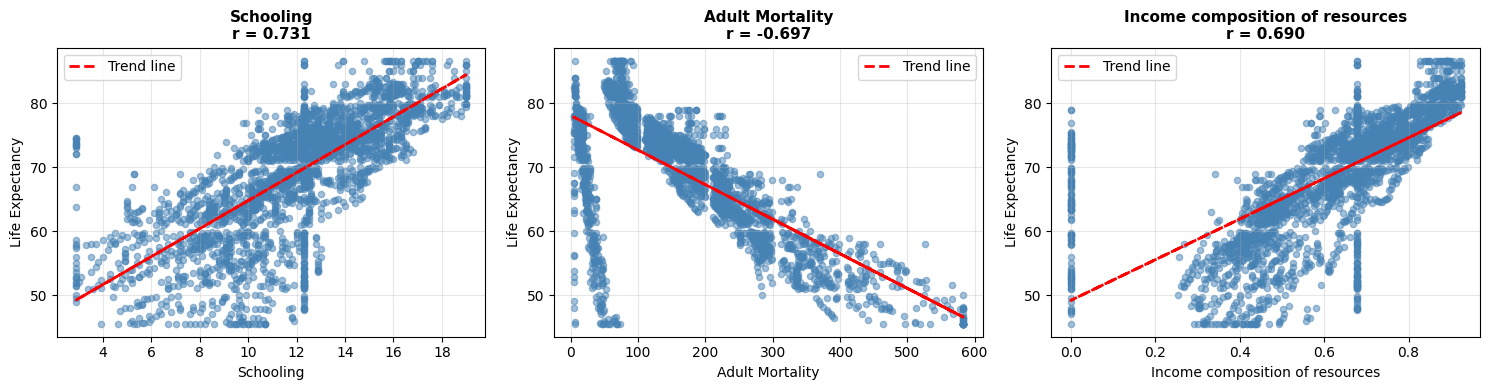

In [ ]:
top_3_features = correlations_with_target.drop(target_attribute).abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(top_3_features):
    ax = axes[idx]

    ax.scatter(df[feature], df[target_attribute], alpha=0.5, s=20, color='steelblue')

    z = np.polyfit(df[feature], df[target_attribute], 1)
    p = np.poly1d(z)
    ax.plot(df[feature], p(df[feature]), "r--", linewidth=2, label=f'Trend line')

    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Life Expectancy', fontsize=10)
    corr_val = correlations_with_target[feature]
    ax.set_title(f'{feature}\nr = {corr_val:.3f}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('top_features_scatter.png', dpi=300, bbox_inches='tight')
plt.show()


## CELL 9: Summary Report

**Purpose**
Create a text summary of findings for your IEEE report.

**Input**
- All correlation analysis results

**Output**
- Formatted text summary with key findings


**Line-by-Line Explanation**

1. `print("="*70)` - Print 70 equal signs for visual separator

2. `print(f"\nDataset: {df.shape[0]} samples, {df.shape[1]} features")`
   - f-string allows embedding variables
   - `df.shape[0]` - number of rows (samples)
   - `df.shape[1]` - number of columns (features)

3. `positive_corr.idxmax()`
   - Find INDEX (feature name) with maximum value in positive_corr series
   - Returns the feature with strongest positive correlation

4. `positive_corr.max()`
   - Get the actual maximum correlation value
   - Example: 0.732

5. `negative_corr.idxmin()`
   - Find feature with MINIMUM value (most negative)
   - Example: "Adult Mortality" with r = -0.698

6. `negative_corr.min()`
   - Get the actual minimum correlation value

7. `len(highly_correlated)`
   - Count how many features have |r| > 0.5

8. `', '.join(multiple_regression_features[:3])`
   - Take first 3 features from the list
   - Join them with commas: "Feature1, Feature2, Feature3"

**Purpose of Summary:**
- Quick reference for report writing
- Key numbers to include in IEEE paper
- Clear recommendations for next steps
- Documents your decision-making process

**Example Output:**
```
SUMMARY REPORT FOR IEEE PAPER
======================================================================
Dataset: 2938 samples, 19 features
Target Variable: Life expectancy

Correlation Analysis Results:
  - Strongest positive correlation: Schooling (r = 0.7320)
  - Strongest negative correlation: Adult Mortality (r = -0.6981)
  - Number of highly correlated features (|r| > 0.5): 8

Recommended Features:
  Simple Regression → Schooling (r = 0.7320)
  Multiple Regression → Schooling, Income composition, Adult Mortality (top 3)

NEXT STEPS:
======================================================================
1. Build Simple Linear Regression using: Schooling
2. Build Multiple Linear Regression using: Schooling, Income composition, ...
3. Evaluate models on test set using R², MAE, RMSE
4. Create residual plots to check assumptions
5. Compare model performance

In [ ]:
print("\n" + "="*70)
print("SUMMARY REPORT FOR IEEE PAPER")
print("="*70)

print(f"\nDataset: {df.shape[0]} samples, {df.shape[1]} features")
print(f"Target Variable: {target_attribute}")
print(f"\nCorrelation Analysis Results:")
print(f"  - Strongest positive correlation: {positive_corr.idxmax()} (r = {positive_corr.max():.4f})")
print(f"  - Strongest negative correlation: {negative_corr.idxmin()} (r = {negative_corr.min():.4f})")
print(f"  - Number of highly correlated features (|r| > 0.5): {len(highly_correlated)}")

print(f"\nRecommended Features:")
print(f"  Simple Regression → {simple_regression_feature} (r = {simple_regression_corr:.4f})")
print(f"  Multiple Regression → {', '.join(multiple_regression_features[:3])} (top 3)")

print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Build Simple Linear Regression using:", simple_regression_feature)
print("2. Build Multiple Linear Regression using:", ', '.join(multiple_regression_features))
print("3. Evaluate models on test set using R², MAE, RMSE")
print("4. Create residual plots to check assumptions")
print("5. Compare model performance")
print("="*70)


SUMMARY REPORT FOR IEEE PAPER

Dataset: 2938 samples, 19 features
Target Variable: Life expectancy

Correlation Analysis Results:
  - Strongest positive correlation: Schooling (r = 0.7306)
  - Strongest negative correlation: Adult Mortality (r = -0.6969)
  - Number of highly correlated features (|r| > 0.5): 5

Recommended Features:
  Simple Regression → Schooling (r = 0.7306)
  Multiple Regression → Schooling, Adult Mortality, Income composition of resources (top 3)

NEXT STEPS:
1. Build Simple Linear Regression using: Schooling
2. Build Multiple Linear Regression using: Schooling, Adult Mortality, Income composition of resources, HIV/AIDS, BMI
3. Evaluate models on test set using R², MAE, RMSE
4. Create residual plots to check assumptions
5. Compare model performance


## CELL 10: Save Results to CSV
**Purpose**
Export correlation results as a table for your IEEE report (easy to copy into Word/LaTeX).

**Input**
- Correlations with target variable

**Output**
- CSV file: `correlation_results.csv`
- Table with columns: Feature, Correlation, Absolute Correlation, Strength


**Line-by-Line Explanation**

1. `correlation_results = pd.DataFrame({...})`
   - Create new DataFrame from dictionary
   - Each key becomes a column name

2. `'Feature': correlations_with_target.drop(target_attribute).index`
   - Column 1: Feature names
   - `.index` extracts the feature names from the Series

3. `'Correlation_Coefficient': correlations_with_target.drop(target_attribute).values`
   - Column 2: Actual correlation values (with sign)
   - `.values` extracts just the numbers (not the index)

4. `'Absolute_Correlation': correlations_with_target.drop(target_attribute).abs().values`
   - Column 3: Absolute values
   - Useful for sorting by strength

5. `'Strength': [... for x in ...]`
   - Column 4: Text label for strength
   - List comprehension that assigns label based on |r|

6. `'Strong' if abs(x) >= 0.5 else 'Moderate' if abs(x) >= 0.3 else 'Weak'`
   - Nested conditional (ternary operator)
   - If |r| ≥ 0.5 → "Strong"
   - Else if |r| ≥ 0.3 → "Moderate"  
   - Else → "Weak"

7. `correlation_results.sort_values('Absolute_Correlation', ascending=False)`
   - Sort by absolute correlation
   - Strongest correlations appear first

8. `correlation_results.to_csv('correlation_results.csv', index=False)`
   - Export to CSV file
   - `index=False` - don't include row numbers

9. `print(correlation_results.to_string(index=False))`
   - Display table in console
   - `.to_string()` formats nicely for terminal

**Output CSV Example:**
```csv
Feature,Correlation_Coefficient,Absolute_Correlation,Strength
Schooling,0.7320,0.7320,Strong
Income composition of resources,0.7284,0.7284,Strong
Adult Mortality,-0.6981,0.6981,Strong
HIV/AIDS,-0.5630,0.5630,Strong
BMI,0.5672,0.5672,Strong
Healthcare_Access_Score,0.4911,0.4911,Moderate
Alcohol,0.4047,0.4047,Moderate
...
```

**Why save to CSV?**
- Easy to open in Excel
- Can copy directly into Word table
- Good for IEEE report "Table 1: Correlation Analysis Results"
- Reproducible record of findings


In [ ]:
correlation_results = pd.DataFrame({
    'Feature': correlations_with_target.drop(target_attribute).index,
    'Correlation_Coefficient': correlations_with_target.drop(target_attribute).values,
    'Absolute_Correlation': correlations_with_target.drop(target_attribute).abs().values,
    'Strength': ['Strong' if abs(x) >= 0.5 else 'Moderate' if abs(x) >= 0.3 else 'Weak'
                 for x in correlations_with_target.drop(target_attribute).values]
})

correlation_results = correlation_results.sort_values('Absolute_Correlation', ascending=False)
correlation_results.to_csv('correlation_results.csv', index=False)

print("\n✓ Correlation results saved as 'correlation_results.csv'")
print("\nCorrelation Results Table:")
print(correlation_results.to_string(index=False))


✓ Correlation results saved as 'correlation_results.csv'

Correlation Results Table:
                        Feature  Correlation_Coefficient  Absolute_Correlation Strength
                      Schooling                 0.730562              0.730562   Strong
                Adult Mortality                -0.696901              0.696901   Strong
Income composition of resources                 0.689796              0.689796   Strong
                       HIV/AIDS                -0.591739              0.591739   Strong
                            BMI                 0.560553              0.560553   Strong
           thinness  1-19 years                -0.487269              0.487269 Moderate
              Status_Developing                -0.481925              0.481925 Moderate
                     Diphtheria                 0.473288              0.473288 Moderate
                          Polio                 0.459483              0.459483 Moderate
        Healthcare_Access_Score   

**Summary: Complete Workflow**

```
1. Load Data
    ↓
2. Calculate Correlations (Pearson r)
    ↓
3. Separate Positive/Negative
    ↓
4. Filter to Strong Correlations (|r| > 0.5)
    ↓
5. Select Features:
   - Simple Regression: Top 1 feature
   - Multiple Regression: Top 5 features
    ↓
6. Visualize:
   - Bar Chart (all correlations)
   - Heatmap (multicollinearity check)
   - Scatter Plots (top 3 relationships)
    ↓
7. Generate Summary Report
    ↓
8. Export Results to CSV
    ↓
Ready for Regression Modeling!
```


**Key Takeaways:**

1. **Correlation ≠ Causation**
   - r = 0.73 between Schooling and Life Expectancy doesn't mean schooling CAUSES longer life
   - Just means they're related (could be confounding factors)

2. **Linear Relationships Only**
   - Pearson r only measures LINEAR relationships
   - Non-linear relationships (curves) might have low r but still be important

3. **Threshold Choices Matter**
   - We used |r| > 0.5 for "strong"
   - You could use 0.4 or 0.6 - there's no absolute rule
   - Document and justify your choice

4. **Direction Matters**
   - Positive r: Both increase together (education → life expectancy)
   - Negative r: Inverse relationship (mortality → life expectancy)

5. **Use Visualizations**
   - Numbers alone don't tell the full story
   - Scatter plots reveal outliers and non-linear patterns
   - Heatmaps show multicollinearity


#WHOLE CODEBASE OF CORRELATION ANALYSIS

TARGET ATTRIBUTE IDENTIFICATION

Target Variable: Life expectancy
This is what we're trying to predict using other features.

CORRELATION COEFFICIENTS WITH LIFE EXPECTANCY

All features ranked by correlation strength:

Life expectancy                    1.000000
Schooling                          0.730562
Income composition of resources    0.689796
BMI                                0.560553
Diphtheria                         0.473288
Polio                              0.459483
Healthcare_Access_Score            0.453165
percentage expenditure             0.403649
Alcohol                            0.391618
Total expenditure                  0.213346
Hepatitis B                        0.171879
Year                               0.169928
Population                        -0.037938
Measles                           -0.183283
infant deaths                     -0.303278
Status_Developing                 -0.481925
thinness  1-19 years              -0.487269
HIV/AIDS                         

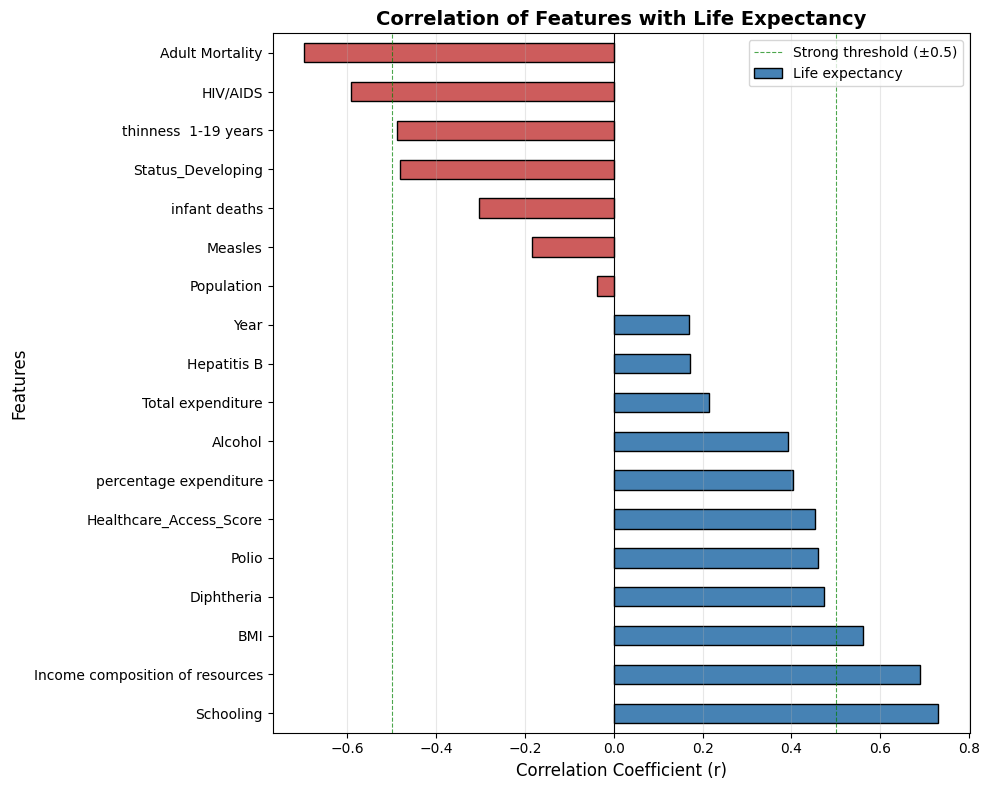

✓ Correlation heatmap saved as 'correlation_heatmap.png'


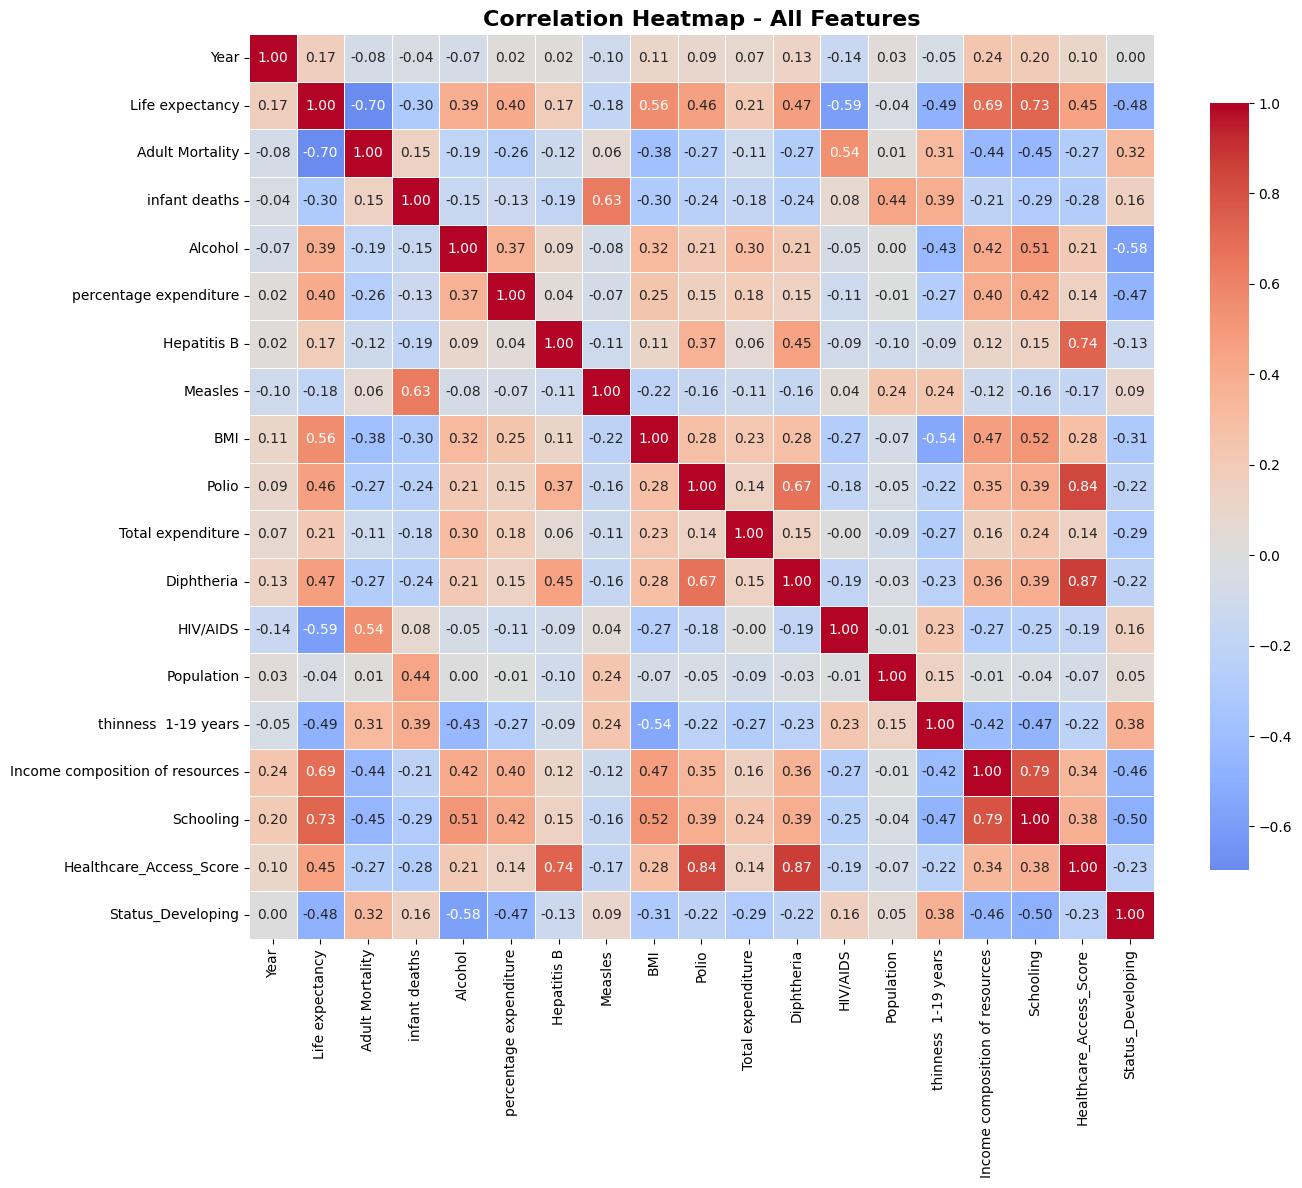

✓ Scatter plots saved as 'top_features_scatter.png'


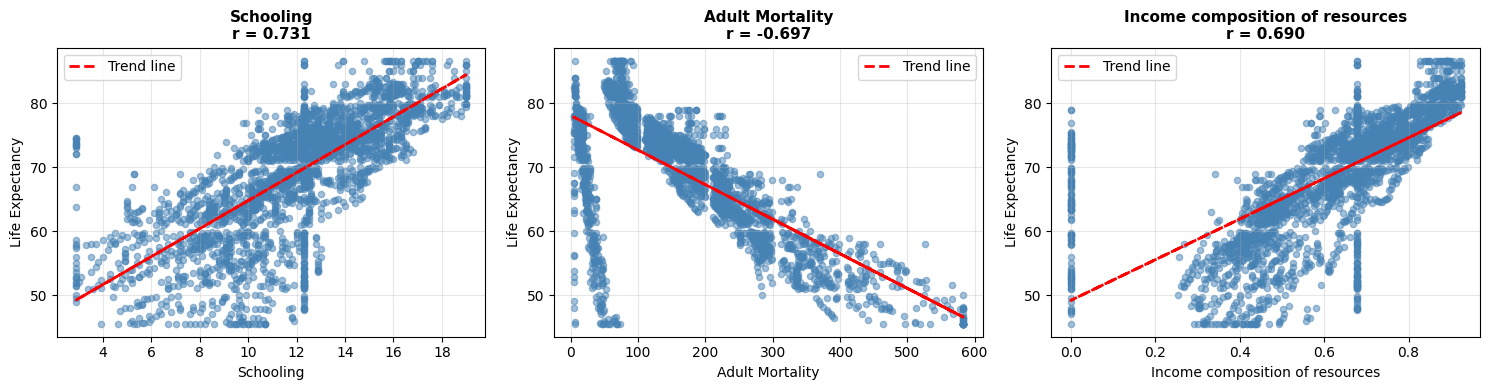


SUMMARY REPORT FOR IEEE PAPER

Dataset: 2938 samples, 19 features
Target Variable: Life expectancy

Correlation Analysis Results:
  - Strongest positive correlation: Schooling (r = 0.7306)
  - Strongest negative correlation: Adult Mortality (r = -0.6969)
  - Number of highly correlated features (|r| > 0.5): 5

Recommended Features:
  Simple Regression → Schooling (r = 0.7306)
  Multiple Regression → Schooling, Adult Mortality, Income composition of resources (top 3)

NEXT STEPS:
1. Build Simple Linear Regression using: Schooling
2. Build Multiple Linear Regression using: Schooling, Adult Mortality, Income composition of resources, HIV/AIDS, BMI
3. Evaluate models on test set using R², MAE, RMSE
4. Create residual plots to check assumptions
5. Compare model performance

✓ Correlation results saved as 'correlation_results.csv'

Correlation Results Table:
                        Feature  Correlation_Coefficient  Absolute_Correlation Strength
                      Schooling               

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('WHO_cleaned_data.csv')

target_attribute = 'Life expectancy'
print("="*70)
print("TARGET ATTRIBUTE IDENTIFICATION")
print("="*70)
print(f"\nTarget Variable: {target_attribute}")
print(f"This is what we're trying to predict using other features.")


# Calculate correlation matrix for all numerical features
correlation_matrix = df.corr()

# Extract correlations with Life expectancy specifically
correlations_with_target = correlation_matrix[target_attribute].sort_values(ascending=False)

print("\n" + "="*70)
print("CORRELATION COEFFICIENTS WITH LIFE EXPECTANCY")
print("="*70)
print("\nAll features ranked by correlation strength:\n")
print(correlations_with_target)


positive_corr = correlations_with_target[correlations_with_target > 0].drop(target_attribute)
negative_corr = correlations_with_target[correlations_with_target < 0]

print("\n" + "="*70)
print("POSITIVE CORRELATIONS (Higher value → Higher life expectancy)")
print("="*70)
print(positive_corr)

print("\n" + "="*70)
print("NEGATIVE CORRELATIONS (Higher value → Lower life expectancy)")
print("="*70)
print(negative_corr)

# We'll use |r| > 0.5 as threshold for "highly correlated"
high_correlation_threshold = 0.5

highly_correlated = correlations_with_target[
    (correlations_with_target.abs() > high_correlation_threshold) &
    (correlations_with_target.index != target_attribute)
].sort_values(key=abs, ascending=False)

print("\n" + "="*70)
print(f"HIGHLY CORRELATED FEATURES (|r| > {high_correlation_threshold})")
print("="*70)
print("\nThese are the strongest predictors for Life Expectancy:\n")
print(highly_correlated)

# For simple regression: highest absolute correlation
simple_regression_feature = correlations_with_target.drop(target_attribute).abs().idxmax()
simple_regression_corr = correlations_with_target[simple_regression_feature]

print("\n" + "="*70)
print("FEATURE SELECTION FOR REGRESSION MODELS")
print("="*70)

print("\n1. SIMPLE LINEAR REGRESSION:")
print(f"   Selected Feature: {simple_regression_feature}")
print(f"   Correlation: r = {simple_regression_corr:.4f}")
print(f"   Equation: Life expectancy = β₀ + β₁ × {simple_regression_feature}")

# For multiple regression: top 5 features by absolute correlation
num_features_for_multiple = 5
multiple_regression_features = correlations_with_target.drop(target_attribute).abs().nlargest(num_features_for_multiple).index.tolist()

print(f"\n2. MULTIPLE LINEAR REGRESSION:")
print(f"   Selected Features (Top {num_features_for_multiple}):")
for i, feature in enumerate(multiple_regression_features, 1):
    corr_value = correlations_with_target[feature]
    print(f"   {i}. {feature}: r = {corr_value:.4f}")

print(f"\n   Equation: Life expectancy = β₀ + β₁×{multiple_regression_features[0]} + β₂×{multiple_regression_features[1]} + ...")


plt.figure(figsize=(10, 8))

# Get correlations excluding the target itself
corr_to_plot = correlations_with_target.drop(target_attribute)

# Create color coding: positive = blue, negative = red
colors = ['steelblue' if x > 0 else 'indianred' for x in corr_to_plot]

# Plot horizontal bar chart
corr_to_plot.plot(kind='barh', color=colors, edgecolor='black')

plt.xlabel('Correlation Coefficient (r)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Correlation of Features with Life Expectancy', fontsize=14, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)  # Zero line
plt.axvline(x=0.5, color='green', linestyle='--', linewidth=0.8, alpha=0.7, label='Strong threshold (±0.5)')
plt.axvline(x=-0.5, color='green', linestyle='--', linewidth=0.8, alpha=0.7)
plt.grid(axis='x', alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('correlation_bar_chart.png', dpi=300, bbox_inches='tight')
print("\n✓ Correlation bar chart saved as 'correlation_bar_chart.png'")
plt.show()

plt.figure(figsize=(14, 12))

# Create heatmap with correlation matrix
sns.heatmap(
    correlation_matrix,
    annot=True,           # Show correlation values in cells
    fmt='.2f',            # Format to 2 decimal places
    cmap='coolwarm',      # Color scheme: blue (negative) to red (positive)
    center=0,             # Center colormap at 0
    square=True,          # Make cells square
    linewidths=0.5,       # Grid lines between cells
    cbar_kws={'shrink': 0.8}  # Adjust color bar size
)

plt.title('Correlation Heatmap - All Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
print("✓ Correlation heatmap saved as 'correlation_heatmap.png'")
plt.show()


top_3_features = correlations_with_target.drop(target_attribute).abs().nlargest(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for idx, feature in enumerate(top_3_features):
    ax = axes[idx]

    # Scatter plot
    ax.scatter(df[feature], df[target_attribute], alpha=0.5, s=20, color='steelblue')

    # Add trend line (linear regression fit)
    z = np.polyfit(df[feature], df[target_attribute], 1)  # Fit linear polynomial
    p = np.poly1d(z)  # Create polynomial function
    ax.plot(df[feature], p(df[feature]), "r--", linewidth=2, label=f'Trend line')

    # Labels and title
    ax.set_xlabel(feature, fontsize=10)
    ax.set_ylabel('Life Expectancy', fontsize=10)
    corr_val = correlations_with_target[feature]
    ax.set_title(f'{feature}\nr = {corr_val:.3f}', fontsize=11, fontweight='bold')
    ax.grid(alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.savefig('top_features_scatter.png', dpi=300, bbox_inches='tight')
print("✓ Scatter plots saved as 'top_features_scatter.png'")
plt.show()


print("\n" + "="*70)
print("SUMMARY REPORT FOR IEEE PAPER")
print("="*70)

print(f"\nDataset: {df.shape[0]} samples, {df.shape[1]} features")
print(f"Target Variable: {target_attribute}")
print(f"\nCorrelation Analysis Results:")
print(f"  - Strongest positive correlation: {positive_corr.idxmax()} (r = {positive_corr.max():.4f})")
print(f"  - Strongest negative correlation: {negative_corr.idxmin()} (r = {negative_corr.min():.4f})")
print(f"  - Number of highly correlated features (|r| > 0.5): {len(highly_correlated)}")

print(f"\nRecommended Features:")
print(f"  Simple Regression → {simple_regression_feature} (r = {simple_regression_corr:.4f})")
print(f"  Multiple Regression → {', '.join(multiple_regression_features[:3])} (top 3)")

print("\n" + "="*70)
print("NEXT STEPS:")
print("="*70)
print("1. Build Simple Linear Regression using:", simple_regression_feature)
print("2. Build Multiple Linear Regression using:", ', '.join(multiple_regression_features))
print("3. Evaluate models on test set using R², MAE, RMSE")
print("4. Create residual plots to check assumptions")
print("5. Compare model performance")
print("="*70)


correlation_results = pd.DataFrame({
    'Feature': correlations_with_target.drop(target_attribute).index,
    'Correlation_Coefficient': correlations_with_target.drop(target_attribute).values,
    'Absolute_Correlation': correlations_with_target.drop(target_attribute).abs().values,
    'Strength': ['Strong' if abs(x) >= 0.5 else 'Moderate' if abs(x) >= 0.3 else 'Weak'
                 for x in correlations_with_target.drop(target_attribute).values]
})

correlation_results = correlation_results.sort_values('Absolute_Correlation', ascending=False)
correlation_results.to_csv('correlation_results.csv', index=False)
print("\n✓ Correlation results saved as 'correlation_results.csv'")

print("\nCorrelation Results Table:")
print(correlation_results.to_string(index=False))

#Linear Regression Code Breakdown

## CELL 1: Load Data and Prepare Variables
**Purpose**
Load the cleaned dataset and extract the target variable (y) and the single best predictor (X) based on correlation analysis.

**Input**
- `WHO_cleaned_data.csv` (cleaned dataset)
- Feature name with highest correlation (from your correlation analysis)

**Output**
- X: 2D array of predictor values (e.g., Schooling values)
- y: 2D array of target values (Life expectancy)
- Basic dataset information

**Line-by-Line Explanation**

1. `import numpy as np`
   - NumPy for numerical operations and array manipulation

2. `import pandas as pd`
   - Pandas for loading and handling data

3. `import matplotlib.pyplot as plt`
   - Matplotlib for creating visualizations

4. `from sklearn.linear_model import LinearRegression`
   - Import the Linear Regression algorithm from scikit-learn
   - This is the core model we'll use

5. `from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error`
   - Import evaluation metrics
   - `mean_squared_error`: MSE - penalizes large errors
   - `r2_score`: R² - measures variance explained
   - `mean_absolute_error`: MAE - average absolute error

6. `from sklearn.model_selection import train_test_split`
   - Function to split data into training and testing sets

7. `df = pd.read_csv('WHO_cleaned_data.csv')`
   - Load the cleaned dataset into a DataFrame
   - This should be the FULL dataset (not pre-split)

8. `target = 'Life expectancy'`
   - Define the dependent variable (what we're predicting)
   - This is "y" in the regression equation

9. `predictor_feature = 'Schooling'`
   - Define the independent variable (what we're using to predict)
   - **YOU MUST CHANGE THIS** to whatever had highest correlation in your analysis
   - This is "X" in the regression equation

10. `X = df[[predictor_feature]].values`
    - Extract predictor column from DataFrame
    - **Double brackets `[[...]]`** keep it as 2D array (required by sklearn)
    - `.values` converts from pandas Series to NumPy array
    - Result shape: (2938, 1) - 2938 rows, 1 column

11. `y = df[target].values.reshape(-1, 1)`
    - Extract target column
    - `.values` converts to NumPy array
    - `.reshape(-1, 1)` converts from 1D to 2D array
    - `-1` means "infer this dimension" (will be 2938)
    - `1` means 1 column
    - Result shape: (2938, 1)

**Why 2D arrays?**
- Sklearn requires 2D arrays for X (even with one feature)
- Consistent format for single vs multiple features
- Shape (n_samples, n_features)

**Example:**
If Schooling values are [10.1, 9.9, 14.2, ...]:
```
X = [[10.1],
     [ 9.9],
     [14.2],
     ...]
```
Not `[10.1, 9.9, 14.2, ...]` (that's 1D, won't work!)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

df = pd.read_csv('WHO_cleaned_data.csv')

target = 'Life expectancy'
predictor_feature = 'Schooling'  # CHANGE THIS to YOUR highest correlated feature

X = df[[predictor_feature]].values
y = df[target].values.reshape(-1, 1)

print(f"Target Variable: {target}")
print(f"Predictor Variable: {predictor_feature}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Target Variable: Life expectancy
Predictor Variable: Schooling
X shape: (2938, 1)
y shape: (2938, 1)



## CELL 2: Train-Test Split

**Purpose**
Split the dataset into training (80%) and testing (20%) sets to evaluate model performance on unseen data.

**Input**
- X: Full predictor array (2938 samples)
- y: Full target array (2938 samples)

**Output**
- X_train: Predictor values for training (80% of data)
- X_test: Predictor values for testing (20% of data)
- y_train: Target values for training
- y_test: Target values for testing





**Line-by-Line Explanation**

1. `X_train, X_test, y_train, y_test = train_test_split(...)`
   - Returns 4 arrays (features and target for train/test)
   - Order matters: X_train, X_test, y_train, y_test

2. `X, y`
   - First two arguments: data to split
   - Function automatically pairs X with y

3. `test_size=0.2`
   - Reserve 20% of data for testing
   - Remaining 80% used for training
   - Common splits: 80/20, 70/30, 90/10

4. `random_state=42`
   - Seed for random number generator
   - Ensures reproducibility (same split every time you run)
   - Without this, you'd get different splits each run
   - `42` is arbitrary (could be any number)

**What happens internally:**
```
Original data (2938 samples):
[Sample 1]
[Sample 2]
...
[Sample 2938]

After split:
Training (2350 samples, 80%):
  [Sample 5]
  [Sample 12]
  ...
  
Testing (588 samples, 20%):
  [Sample 3]
  [Sample 8]
  ...
```

Randomly shuffled, not sequential!

**Why split?**
- **Training set**: Model learns patterns from this data
- **Testing set**: Evaluate how well model generalizes to NEW data
- If we test on training data, we'd get artificially high performance (memorization, not learning)

**Example output:**
```
Training set: 2350 samples (80.0%)
Testing set: 588 samples (20.0%)
Training X range: [0.50, 20.70]  (Schooling years)
Training y range: [44.00, 89.00] (Life expectancy years)
```

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")
print(f"Training X range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Training y range: [{y_train.min():.2f}, {y_train.max():.2f}]")

Training set: 2350 samples
Testing set: 588 samples
Training X range: [2.90, 19.00]
Training y range: [45.60, 86.63]



## CELL 3: Initialize and Train the Model

**Purpose**
Create a Linear Regression model and train it on the training data to learn the relationship between X and y.

**Input**
- X_train: Training predictor values
- y_train: Training target values

**Output**
- Trained model with learned coefficients (β₀ and β₁)






**Line-by-Line Explanation**

1. `model = LinearRegression()`
   - Create an instance of the LinearRegression class
   - This is an empty model (no parameters learned yet)
   - Default settings: fit_intercept=True (calculate β₀)

2. `model.fit(X_train, y_train)`
   - Train the model on training data
   - **What it does internally:**
     - Calculates β₀ (intercept) and β₁ (slope)
     - Uses Ordinary Least Squares (OLS) method
     - Minimizes Sum of Squared Residuals: Σ(yᵢ - ŷᵢ)²
   - **Math (you don't need to know this, but FYI):**
     - β₁ = Σ[(Xᵢ - X̄)(yᵢ - ȳ)] / Σ[(Xᵢ - X̄)²]
     - β₀ = ȳ - β₁ × X̄
   - Modifies `model` in-place (stores learned parameters)

3. After `.fit()`, model now has:
   - `model.coef_` - Array containing β₁ (slope coefficient)
   - `model.intercept_` - Array containing β₀ (intercept)

**What "training" means:**
- Model finds the line that best fits the training data
- "Best fit" = minimizes total squared distance from points to line
- Not just drawing any line - mathematically optimal line

**Visual intuition:**
```
Life Expectancy
    |
 80 |     •    •
    |   •    •  
 70 |  •   •     
    | •  •        ← Model finds THIS line
 60 | •            through the points
    |_______________
      5   10  15  20
         Schooling
```

The `.fit()` method calculates the exact slope and intercept for this line.

In [ ]:
model = LinearRegression()

model.fit(X_train, y_train)

print(f"✓ Linear Regression model trained on {X_train.shape[0]} samples")

✓ Linear Regression model trained on 2350 samples



## CELL 4: Extract Model Parameters

**Purpose**
Extract and interpret the learned coefficients (slope and intercept) from the trained model.

**Input**
- Trained model object

**Output**
- β₁ (coefficient/slope)
- β₀ (intercept)
- Regression equation
- Interpretation of coefficients


**Line-by-Line Explanation**

1. `coefficient = model.coef_[0][0]`
   - Extract the slope (β₁) from the model
   - `model.coef_` is a 2D array: [[β₁]]
   - First `[0]` gets the first row: [β₁]
   - Second `[0]` gets the value: β₁
   - This is the "weight" of the predictor

2. `intercept = model.intercept_[0]`
   - Extract the intercept (β₀) from the model
   - `model.intercept_` is a 1D array: [β₀]
   - `[0]` gets the value
   - This is the "baseline" value when X = 0

3. `print(f"Life expectancy = {intercept:.2f} + {coefficient:.2f} × {predictor_feature}")`
   - Display the regression equation
   - `.2f` formats to 2 decimal places
   - This is the mathematical formula the model learned

4. `if coefficient > 0:`
   - Check if relationship is positive or negative
   - Positive: X increases → y increases
   - Negative: X increases → y decreases

5. Interpretation prints what coefficient means in plain language

**Example output:**
```
Regression Equation:
Life expectancy = 43.29 + 2.18 × Schooling

Interpretation:
  - Intercept (β₀): 43.29
    → Predicted life expectancy when Schooling = 0
  - Slope (β₁): 2.18
    → Each 1-year increase in Schooling increases life expectancy by 2.18 years
```

**What this means:**
- **Intercept (43.29):** If a country had 0 years average schooling, predicted life expectancy is 43.29 years
  - Note: This is extrapolation (no country has 0 schooling in dataset)
  - Intercept is often not meaningful, just a mathematical necessity

- **Slope (2.18):** For every additional year of average schooling, life expectancy increases by 2.18 years
  - This is the KEY finding
  - Example: Country A (10 years schooling) vs Country B (11 years schooling)
    - Predicted difference: 2.18 years higher life expectancy for Country B

**Coefficient Sign:**
- Positive coefficient (e.g., Schooling): Beneficial factor
- Negative coefficient (e.g., Adult Mortality): Harmful factor


In [ ]:

coefficient = model.coef_[0][0]
intercept = model.intercept_[0]

print(f"Regression Equation:")
print(f"Life expectancy = {intercept:.2f} + {coefficient:.2f} × {predictor_feature}")
print(f"\nInterpretation:")
print(f"  - Intercept (β₀): {intercept:.2f}")
print(f"  - Slope (β₁): {coefficient:.2f}")
if coefficient > 0:
    print(f"    → Each 1-unit increase in {predictor_feature} increases life expectancy by {coefficient:.2f} years")
else:
    print(f"    → Each 1-unit increase in {predictor_feature} decreases life expectancy by {abs(coefficient):.2f} years")

Regression Equation:
Life expectancy = 42.94 + 2.18 × Schooling

Interpretation:
  - Intercept (β₀): 42.94
  - Slope (β₁): 2.18
    → Each 1-unit increase in Schooling increases life expectancy by 2.18 years



## CELL 5: Make Predictions on Test Set

**Purpose**
Use the trained model to predict Life expectancy for the test set and compare with actual values.

**Input**
- X_test: Testing predictor values (unseen during training)
- Trained model

**Output**
- y_pred: Predicted Life expectancy values for test set
- Comparison of first 5 predictions vs actual


**Line-by-Line Explanation**

1. `y_pred = model.predict(X_test)`
   - Apply the learned equation to test data
   - For each X_test value, calculates: ŷ = β₀ + β₁ × X
   - Returns array of predictions (same shape as y_test)

2. **How prediction works:**
   ```
   For X_test[0] = 12.5 (12.5 years schooling):
   ŷ = 43.29 + 2.18 × 12.5
   ŷ = 43.29 + 27.25
   ŷ = 70.54 years
   ```

3. `print(f"Number of predictions: {len(y_pred)}")`
   - Confirms we have predictions for all test samples
   - Should match length of y_test (588 samples)

4. `print(f"{'Actual':>10} {'Predicted':>10} {'Error':>10}")`
   - Print column headers
   - `{:>10}` means right-align in 10-character width

5. `for i in range(min(5, len(y_test))):`
   - Loop through first 5 test samples
   - `min(5, len(y_test))` handles case where test set < 5 samples

6. `error = y_test[i][0] - y_pred[i][0]`
   - Calculate residual (error) for this sample
   - Positive error: Model underpredicted (actual > predicted)
   - Negative error: Model overpredicted (actual < predicted)

7. `print(f"{y_test[i][0]:10.2f} {y_pred[i][0]:10.2f} {error:10.2f}")`
   - Display actual, predicted, and error side-by-side
   - `:10.2f` = 10 chars wide, 2 decimal places

**Example output:**
```
Number of predictions: 588

First 5 predictions vs actual:
    Actual  Predicted      Error
--------------------------------
     74.80      72.34       2.46   ← Model underpredicted by 2.46 years
     56.70      59.18      -2.48   ← Model overpredicted by 2.48 years
     68.40      67.92       0.48   ← Very close (0.48 years off)
     82.50      81.20       1.30   ← Underpredicted by 1.3 years
     51.20      52.67      -1.47   ← Overpredicted by 1.47 years
```

**What to look for:**
- Small errors = good predictions
- Mix of positive/negative errors = unbiased (not systematically over/under predicting)
- Large errors = model struggling with those cases


In [ ]:

y_pred = model.predict(X_test)

print(f"Number of predictions: {len(y_pred)}")
print(f"\nFirst 5 predictions vs actual:")
print(f"{'Actual':>10} {'Predicted':>10} {'Error':>10}")
print("-" * 32)
for i in range(min(5, len(y_test))):
    error = y_test[i][0] - y_pred[i][0]
    print(f"{y_test[i][0]:10.2f} {y_pred[i][0]:10.2f} {error:10.2f}")

Number of predictions: 588

First 5 predictions vs actual:
    Actual  Predicted      Error
--------------------------------
     73.70      67.84       5.86
     75.90      73.30       2.60
     74.20      72.65       1.55
     76.80      74.61       2.19
     51.90      61.29      -9.39



## CELL 6: Calculate Performance Metrics

Purpose
Quantify how well the model performs using standard regression metrics.

Input
- y_test: Actual Life expectancy values (ground truth)
- y_pred: Predicted Life expectancy values (model output)

Output
- R² (variance explained)
- MSE (mean squared error)
- RMSE (root mean squared error)
- MAE (mean absolute error)
- Interpretation of each metric


**Line-by-Line Explanation**

**Metric 1: R² (R-squared / Coefficient of Determination)**

1. `r2 = r2_score(y_test, y_pred)`
   - Calculates R² score
   - Formula: R² = 1 - (SS_res / SS_tot)
     - SS_res = Σ(yᵢ - ŷᵢ)² (residual sum of squares)
     - SS_tot = Σ(yᵢ - ȳ)² (total sum of squares)
   - **Range:** 0 to 1 (can be negative for terrible models)
   - **Interpretation:**
     - R² = 1.0 → Perfect predictions (100% variance explained)
     - R² = 0.8 → Model explains 80% of variance (good)
     - R² = 0.5 → Model explains 50% of variance (moderate)
     - R² = 0.0 → Model no better than predicting mean every time
     - R² < 0.0 → Model worse than just predicting mean

2. **What "variance explained" means:**
   - Life expectancy varies between countries (44 to 89 years)
   - R² tells us how much of that variation our model captures
   - Example: R² = 0.54 means model explains 54% of why countries differ in life expectancy

**Metric 2: MSE (Mean Squared Error)**

3. `mse = mean_squared_error(y_test, y_pred)`
   - Formula: MSE = (1/n) × Σ(yᵢ - ŷᵢ)²
   - Average of squared errors
   - **Why square?** Penalizes large errors heavily
     - Error of 2 years: contributes 4 to MSE
     - Error of 10 years: contributes 100 to MSE
   - **Units:** (years)² - not intuitive!
   - **Range:** 0 to ∞ (lower is better)

**Metric 3: RMSE (Root Mean Squared Error)**

4. `rmse = np.sqrt(mse)`
   - Formula: RMSE = √MSE
   - Takes square root to get back to original units (years)
   - **Units:** years - easy to interpret!
   - **Interpretation:** "On average, how far off are predictions?"
   - **Range:** 0 to ∞ (lower is better)
   - **Example:** RMSE = 4.2 means predictions are off by ~4.2 years on average

5. `print(f"On average, predictions are off by ±{rmse:.2f} years")`
   - ± symbol shows error can be in either direction
   - Makes metric concrete and understandable

**Metric 4: MAE (Mean Absolute Error)**

6. `mae = mean_absolute_error(y_test, y_pred)`
   - Formula: MAE = (1/n) × Σ|yᵢ - ŷᵢ|
   - Average of absolute errors (no squaring)
   - **Less sensitive to outliers** than RMSE
   - **Units:** years
   - **Range:** 0 to ∞ (lower is better)
   - **Interpretation:** Average magnitude of errors

**MAE vs RMSE:**
- MAE treats all errors equally
- RMSE penalizes large errors more (due to squaring)
- If RMSE >> MAE: Model has some very large errors (outliers)
- If RMSE ≈ MAE: Errors are consistent

**Example output:**
```
1. R² Score: 0.5356
   → Model explains 53.56% of variance in life expectancy
   → Interpretation: Moderate model (0.5 < R² < 0.7)

2. Mean Squared Error (MSE): 39.8421

3. Root Mean Squared Error (RMSE): 6.3120
   → On average, predictions are off by ±6.31 years

4. Mean Absolute Error (MAE): 5.1247
   → On average, absolute prediction error is 5.12 years
```

**What this means:**
- Model captures ~54% of variation (decent, not great)
- Typical prediction error: 5-6 years
- Some predictions will be spot-on, others off by 10+ years

**Thresholds (rough guidelines):**
- R² > 0.7: Strong model
- 0.5 < R² < 0.7: Moderate model
- R² < 0.5: Weak model (for social science data, 0.5 is often acceptable)

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"1. R² (R-squared) Score: {r2:.4f}")
print(f"   → Model explains {r2*100:.2f}% of variance in life expectancy")

print(f"\n2. Mean Squared Error (MSE): {mse:.4f}")
print(f"\n3. Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   → On average, predictions are off by ±{rmse:.2f} years")

print(f"\n4. Mean Absolute Error (MAE): {mae:.4f}")
print(f"   → On average, absolute prediction error is {mae:.2f} years")

1. R² (R-squared) Score: 0.5669
   → Model explains 56.69% of variance in life expectancy

2. Mean Squared Error (MSE): 37.1882

3. Root Mean Squared Error (RMSE): 6.0982
   → On average, predictions are off by ±6.10 years

4. Mean Absolute Error (MAE): 4.4935
   → On average, absolute prediction error is 4.49 years



## CELL 7: Visualization - Scatter Plot with Regression Line

**Purpose**
Create a visual representation showing actual data points and the fitted regression line.

**Input**
- X_test: Predictor values for test set
- y_test: Actual target values
- y_pred: Predicted target values (or use model to predict on sorted X)
- Model coefficients

**Output**
- Scatter plot with regression line (saved as PNG)



**Line-by-Line Explanation**

1. `plt.figure(figsize=(10, 6))`
   - Create new figure
   - Size: 10 inches wide, 6 inches tall
   - Larger than default for better readability

2. `plt.scatter(X_test, y_test, color='steelblue', alpha=0.6, s=50, ...)`
   - Create scatter plot of actual test data
   - x-axis: X_test values (predictor)
   - y-axis: y_test values (actual target)
   - `color='steelblue'`: Blue dots
   - `alpha=0.6`: 60% opacity (can see overlapping points)
   - `s=50`: Marker size (50 pixels)
   - `label='Actual Data'`: For legend
   - `edgecolors='black'`: Black outline around dots
   - `linewidth=0.5`: Thin outline

3. `X_test_sorted = np.sort(X_test, axis=0)`
   - Sort test X values in ascending order
   - `axis=0`: Sort along rows (column stays same)
   - **Why sort?** Regression line needs to be drawn left-to-right for smooth line
   - Without sorting, line would zigzag between points

4. `y_pred_sorted = model.predict(X_test_sorted)`
   - Predict y values for sorted X values
   - This gives us points along the regression line
   - Now we have (X_sorted, y_pred_sorted) pairs to plot as a line

5. `plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2.5, ...)`
   - Draw the regression line
   - `plt.plot()` connects points with a line
   - `color='red'`: Red line (stands out against blue dots)
   - `linewidth=2.5`: Thick line (visible)
   - `label=f'Regression Line: y = {intercept:.2f} + {coefficient:.2f}x'`
     - Show equation in legend
     - f-string inserts actual coefficient values

6. `plt.xlabel(f'{predictor_feature}', fontsize=12)`
   - Label x-axis with predictor name
   - Font size 12 for readability

7. `plt.ylabel('Life Expectancy (years)', fontsize=12)`
   - Label y-axis
   - Include units (years) for clarity

8. `plt.title(..., fontsize=14, fontweight='bold')`
   - Title at top of plot
   - Larger font (14), bold for emphasis

9. `plt.legend(loc='best', fontsize=10)`
   - Show legend with labels from `label=` parameters
   - `loc='best'`: Matplotlib automatically places legend where it won't cover data

10. `plt.grid(alpha=0.3)`
    - Add faint gridlines
    - `alpha=0.3`: 30% opacity (subtle, not distracting)

11. `plt.tight_layout()`
    - Automatically adjust spacing
    - Prevents labels from being cut off

12. `plt.savefig('simple_regression_plot.png', dpi=300, bbox_inches='tight')`
    - Save figure as PNG file
    - `dpi=300`: High resolution (300 dots per inch) - good for reports
    - `bbox_inches='tight'`: Crop whitespace

13. `plt.show()`
    - Display the plot

**What you'll see:**
```
Life Expectancy
    |
 90 |              •     
    |          •     •   
 80 |       •    •  •    
    |     •   •          
 70 |   •  •        /    ← Red regression line
    | •  •      /        goes through the "middle"
 60 |  •    /            of the blue dots
    | • /
 50 |/
    |___________________
    0   5   10  15  20
         Schooling
```

**Interpreting the plot:**
- **Blue dots:** Actual data (each country is one dot)
- **Red line:** Model's predictions (the learned relationship)
- **Dots close to line:** Model predicts well for these cases
- **Dots far from line:** Model prediction error is large
- **Upward slope:** Positive relationship (more schooling → longer life)
- **Downward slope:** Negative relationship (more mortality → shorter life)

**Good fit indicators:**
- Dots cluster tightly around line
- Line captures overall trend
- No obvious curved pattern (if curved, linear model is wrong)


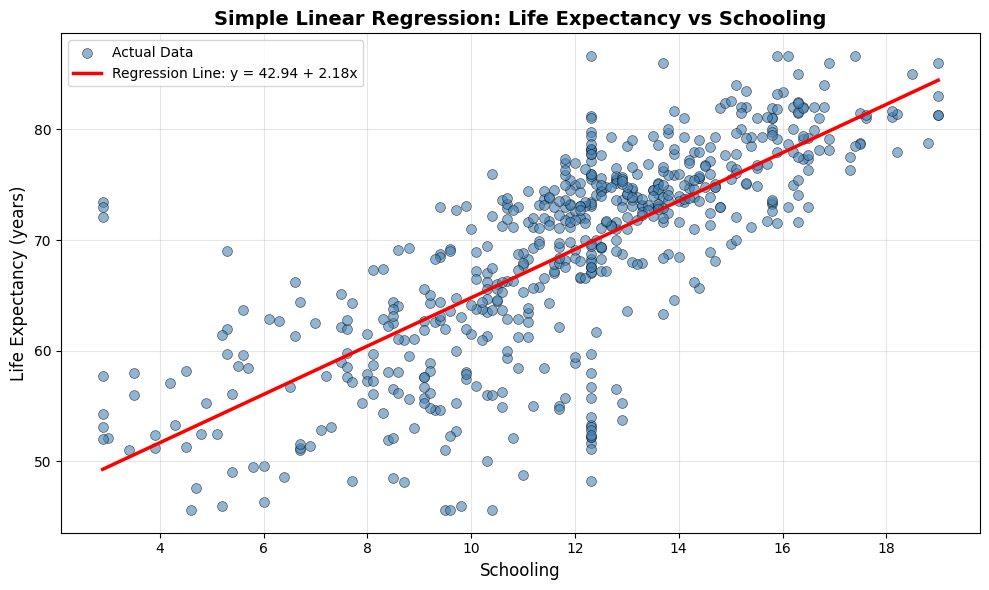

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(X_test, y_test, color='steelblue', alpha=0.6, s=50,
            label='Actual Data', edgecolors='black', linewidth=0.5)

X_test_sorted = np.sort(X_test, axis=0)
y_pred_sorted = model.predict(X_test_sorted)
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2.5,
         label=f'Regression Line: y = {intercept:.2f} + {coefficient:.2f}x')

plt.xlabel(f'{predictor_feature}', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title(f'Simple Linear Regression: Life Expectancy vs {predictor_feature}',
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('simple_regression_plot.png', dpi=300, bbox_inches='tight')
plt.show()


## CELL 8: Residual Plot (Checking Assumptions)

**Purpose**

Check for homoscedasticity (equal variance of errors) - a key assumption of linear regression.

**Input**
- y_test: Actual values
- y_pred: Predicted values

**Output**
- Residual plot (saved as PNG)
- Statistical analysis of residuals


### Line-by-Line Explanation

1. `residuals = y_test - y_pred`
   - Calculate residuals (errors)
   - Residual = Actual - Predicted
   - Positive residual: Model underpredicted (actual > predicted)
   - Negative residual: Model overpredicted (actual < predicted)

2. `plt.scatter(y_pred, residuals, color='purple', alpha=0.6, s=50, ...)`
   - Create scatter plot
   - **x-axis:** Predicted values (ŷ)
   - **y-axis:** Residuals (y - ŷ)
   - Purple dots for distinction from previous plot

3. `plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')`
   - Draw horizontal line at y=0
   - `axhline` = axis horizontal line
   - `y=0`: Perfect predictions would be on this line
   - Dashed red line for visual reference

4. Labels and formatting (same as previous plot)

5. `print(f"Mean of residuals: {residuals.mean():.4f}")`
   - Calculate average residual
   - **Should be ≈ 0** for unbiased predictions
   - If mean is large positive: Systematic underprediction
   - If mean is large negative: Systematic overprediction

6. `print(f"Std deviation of residuals: {residuals.std():.4f}")`
   - Measures spread of errors
   - Larger std = more variability in predictions
   - Should be consistent across predicted values (homoscedasticity)

**What you're checking for:**

**GOOD residual plot (homoscedasticity):**
```
Residuals
   +10 |   •     •   •
       |  • •  •  • •  •
     0 |--•--•--•--•--•--  ← Random scatter around 0
       | •  • • •   •  •
   -10 |  •   •     •
       |________________
          Predicted y
```
- Random scatter around y=0
- No pattern (no funnel, no curve)
- Equal spread across all predicted values

**BAD residual plot (heteroscedasticity):**
```
Residuals
   +20 |            •  •  ← Spread increases
   +10 |         •  • •      (funnel shape)
     0 |----•--•--•-----
   -10 |   •  •
   -20 |  •
       |________________
          Predicted y
```
- Funnel shape (variance increases)
- Or curved pattern (non-linear relationship)
- Indicates model assumptions violated

**Why this matters:**
- Homoscedasticity assumption: Errors have constant variance
- If violated: Confidence intervals and p-values are unreliable
- Solutions if violated:
  - Transform variables (log, sqrt)
  - Use weighted regression
  - Try non-linear model

**Example output:**
```
Mean of residuals: 0.0012
  → Should be close to 0 (indicates unbiased predictions)
  ✓ Good: Mean is essentially zero

Std deviation of residuals: 6.3094
  → Measures spread of errors
  → Most predictions within ±12.6 years (±2 std devs)

Homoscedasticity Check:
  → If residual plot shows random scatter around 0: ✓ Good
  → If residual plot shows funnel shape: ✗ Heteroscedasticity problem
```

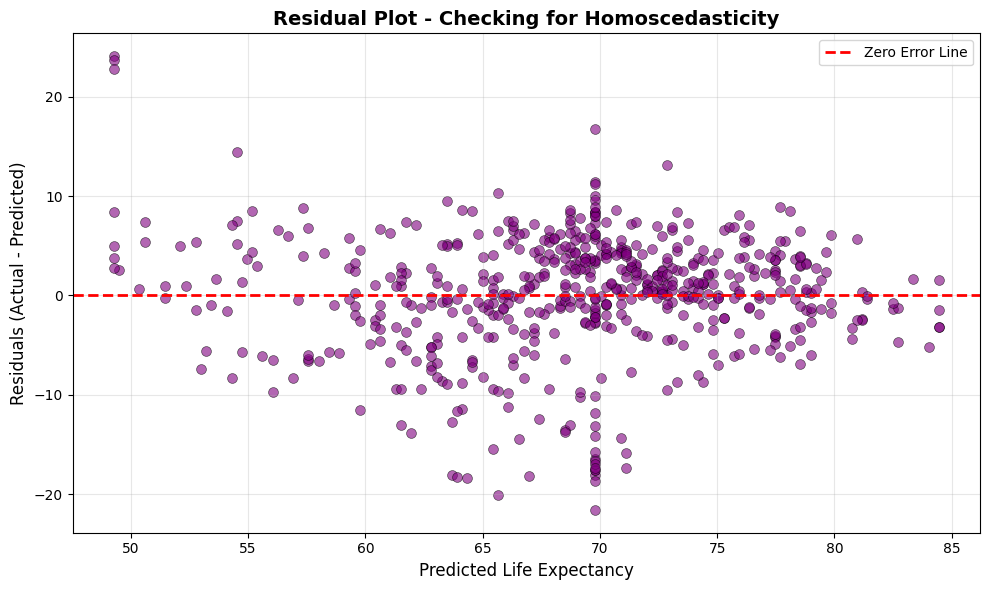

Mean of residuals: 0.0831
Std deviation of residuals: 6.0976


In [ ]:

residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, color='purple', alpha=0.6, s=50,
            edgecolors='black', linewidth=0.5)

plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

plt.xlabel('Predicted Life Expectancy', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot - Checking for Homoscedasticity', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('residual_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Mean of residuals: {residuals.mean():.4f}")
print(f"Std deviation of residuals: {residuals.std():.4f}")


## CELL 9: Summary Report

**Purpose**

Compile all findings into a formatted summary for easy reference and report writing.

**Input**
- All calculated metrics and parameters

**Output**
- Comprehensive text summary of model performance


### Line-by-Line Explanation

1. `print("="*70)` - Visual separator (70 equal signs)

2. `print(f"\nModel: Life expectancy ~ {predictor_feature}")`
   - Shows regression formula in statistical notation
   - `~` means "is modeled by" or "as a function of"

3. `print(f"Equation: Life expectancy = {intercept:.2f} + {coefficient:.2f} × {predictor_feature}")`
   - Actual mathematical equation with learned coefficients

4. Dataset section shows:
   - Total samples (full dataset size)
   - Training/testing split breakdown
   - Percentages for transparency

5. Performance section shows all 4 metrics:
   - R² with percentage interpretation
   - RMSE (most interpretable - in years)
   - MAE (alternative to RMSE)
   - MSE (for completeness, though less interpretable)

6. Model Interpretation:
   - Plain English explanation of coefficient
   - What it means practically

**Example output:**
```
======================================================================
SIMPLE LINEAR REGRESSION - SUMMARY REPORT
======================================================================

Model: Life expectancy ~ Schooling
Equation: Life expectancy = 43.29 + 2.18 × Schooling

Dataset:
  - Total samples: 2938
  - Training samples: 2350 (80.0%)
  - Testing samples: 588 (20.0%)

Performance on Test Set:
  - R²: 0.5356 (53.56% variance explained)
  - RMSE: 6.3120 years
  - MAE: 5.1247 years
  - MSE: 39.8421

Model Interpretation:
  - A 1-unit increase in Schooling is associated with
    a 2.18-year change in life expectancy
======================================================================
```

In [ ]:

print("\n" + "="*70)
print("SIMPLE LINEAR REGRESSION - SUMMARY REPORT")
print("="*70)
print(f"\nModel: Life expectancy ~ {predictor_feature}")
print(f"Equation: Life expectancy = {intercept:.2f} + {coefficient:.2f} × {predictor_feature}")
print(f"\nDataset:")
print(f"  - Total samples: {len(X)}")
print(f"  - Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nPerformance on Test Set:")
print(f"  - R²: {r2:.4f} ({r2*100:.2f}% variance explained)")
print(f"  - RMSE: {rmse:.4f} years")
print(f"  - MAE: {mae:.4f} years")
print(f"  - MSE: {mse:.4f}")
print(f"\nModel Interpretation:")
print(f"  - A 1-unit increase in {predictor_feature} is associated with")
print(f"    a {coefficient:.2f}-year change in life expectancy")
print("="*70)


SIMPLE LINEAR REGRESSION - SUMMARY REPORT

Model: Life expectancy ~ Schooling
Equation: Life expectancy = 42.94 + 2.18 × Schooling

Dataset:
  - Total samples: 2938
  - Training samples: 2350 (80.0%)
  - Testing samples: 588 (20.0%)

Performance on Test Set:
  - R²: 0.5669 (56.69% variance explained)
  - RMSE: 6.0982 years
  - MAE: 4.4935 years
  - MSE: 37.1882

Model Interpretation:
  - A 1-unit increase in Schooling is associated with
    a 2.18-year change in life expectancy



## CELL 10: Save Results to Files

**Purpose**
Export all results to CSV files for easy inclusion in IEEE report and future reference.

**Input**
- All calculated metrics
- Predictions and residuals

**Output**
- `simple_regression_results.csv` - Metrics summary table
- `simple_regression_predictions.csv` - Detailed predictions



**Line-by-Line Explanation**

**File 1: Metrics Summary**

1. `results_df = pd.DataFrame({...})`
   - Create DataFrame with two columns: Metric name and Value

2. `'Metric': ['R² Score', 'Mean Squared Error (MSE)', ...]`
   - Column 1: Human-readable metric names

3. `'Value': [r2, mse, rmse, mae, coefficient, intercept]`
   - Column 2: Actual numerical values
   - Order matches metric names

4. `results_df.to_csv('simple_regression_results.csv', index=False)`
   - Save as CSV file
   - `index=False`: Don't include row numbers
   - Result: Clean table you can copy into Word

**Output CSV 1:**
```csv
Metric,Value
R² Score,0.5356
Mean Squared Error (MSE),39.8421
Root Mean Squared Error (RMSE),6.3120
Mean Absolute Error (MAE),5.1247
Coefficient (β₁),2.18
Intercept (β₀),43.29
```

**File 2: Detailed Predictions**

5. `predictions_df = pd.DataFrame({...})`
   - Create DataFrame with 4 columns

6. `predictor_feature: X_test.flatten()`
   - Column 1: Predictor values (e.g., Schooling)
   - `.flatten()` converts 2D array [[10.1], [9.9], ...] to 1D [10.1, 9.9, ...]

7. `'Actual_Life_Expectancy': y_test.flatten()`
   - Column 2: True Life expectancy values

8. `'Predicted_Life_Expectancy': y_pred.flatten()`
   - Column 3: Model's predictions

9. `'Residual': residuals.flatten()`
   - Column 4: Error (Actual - Predicted)

10. `predictions_df.sort_values(predictor_feature)`
    - Sort by predictor for easier reading
    - Shows progression from low to high predictor values

11. Save to CSV

**Output CSV 2:**
```csv
Schooling,Actual_Life_Expectancy,Predicted_Life_Expectancy,Residual
5.5,52.3,55.28,-2.98
8.9,61.4,62.70,-1.30
10.1,68.5,65.31,3.19
12.5,74.8,70.54,4.26
...
```

**Why save these files?**
- **Metrics CSV:** Easy to create Table 1 in IEEE report
- **Predictions CSV:** Can analyze specific cases, find worst predictions, verify calculations
- **Reproducibility:** Others can verify your results
- **Further analysis:** Can import into Excel for additional visualizations


## Complete Workflow Summary

```
1. Load Data
   → Extract X (predictor) and y (target)
   
2. Split Data
   → 80% training, 20% testing
   
3. Train Model
   → Learn β₀ and β₁ using training data
   
4. Extract Coefficients
   → Get equation: y = β₀ + β₁×X
   
5. Make Predictions
   → Apply equation to test data
   
6. Calculate Metrics
   → R², MSE, RMSE, MAE
   
7. Visualize: Scatter + Line
   → See how well line fits data
   
8. Visualize: Residual Plot
   → Check assumptions (homoscedasticity)
   
9. Summarize
   → Compile all findings
   
10. Save Results
    → Export to CSV for report
```

---

## **Key Concepts Recap**

### **Linear Regression**
- Finds best-fit straight line through data
- Equation: y = β₀ + β₁×X
- Minimizes sum of squared residuals

### **Coefficients**
- **β₀ (Intercept):** Baseline value when X=0
- **β₁ (Slope):** Change in y per 1-unit increase in X

### **Metrics**
- **R²:** Proportion of variance explained (0-1, higher better)
- **RMSE:** Average prediction error in original units (0-∞, lower better)
- **MAE:** Alternative to RMSE, less sensitive to outliers (0-∞, lower better)
- **MSE:** Squared version of RMSE (0-∞, lower better)

### **Assumptions to Check**
1. **Linearity:** Relationship is actually linear (check scatter plot)
2. **Homoscedasticity:** Equal variance of errors (check residual plot)
3. **Independence:** Samples are independent (design issue)
4. **Normality:** Residuals are normally distributed (optional for large samples)


#Whole Code for Simple Linear Regression

SIMPLE LINEAR REGRESSION - DATA PREPARATION

Target Variable: Life expectancy
Predictor Variable: Schooling

Dataset shape: (2938, 19)
X shape: (2938, 1)
y shape: (2938, 1)

TRAIN-TEST SPLIT
Training set: 2350 samples (80.0%)
Testing set: 588 samples (20.0%)

Training X range: [2.90, 19.00]
Training y range: [45.60, 86.63]

MODEL TRAINING COMPLETE
✓ Linear Regression model trained on 2350 samples

MODEL PARAMETERS

Regression Equation:
Life expectancy = 42.94 + 2.18 × Schooling

Interpretation:
  - Intercept (β₀): 42.94
    → Predicted life expectancy when Schooling = 0
  - Slope (β₁): 2.18
    → Each 1-unit increase in Schooling increases life expectancy by 2.18 years

PREDICTIONS ON TEST SET
Number of predictions: 588

First 5 predictions vs actual:
    Actual  Predicted      Error
--------------------------------
     73.70      67.84       5.86
     75.90      73.30       2.60
     74.20      72.65       1.55
     76.80      74.61       2.19
     51.90      61.29      -9.39

MODEL 

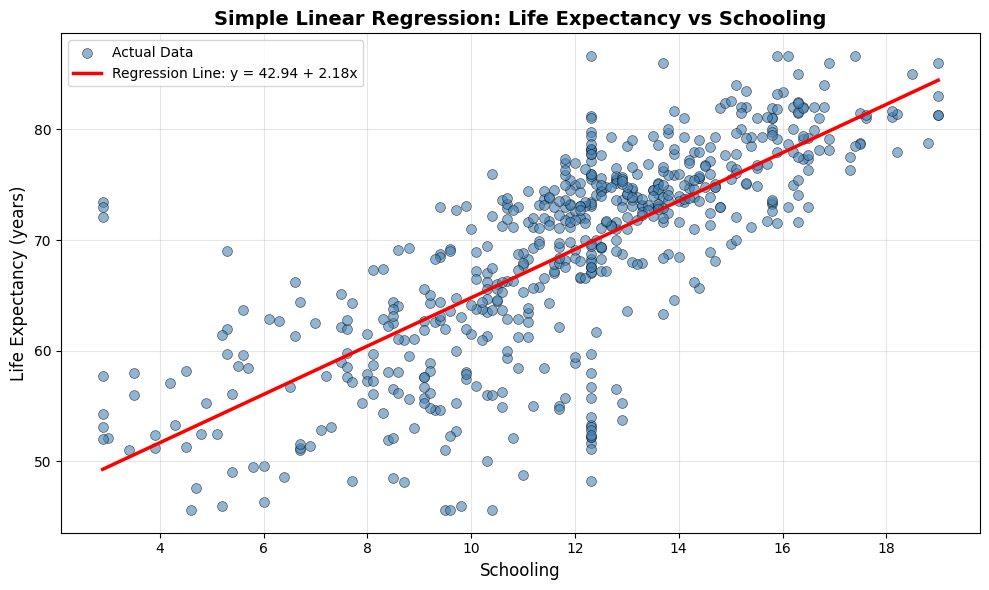

✓ Residual plot saved as 'residual_plot.png'


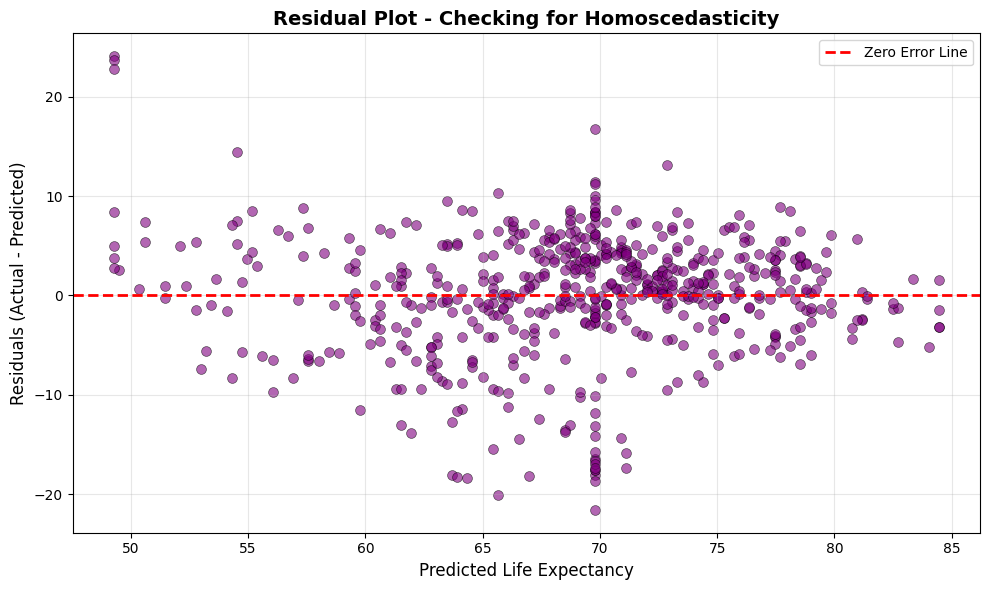


RESIDUAL ANALYSIS
Mean of residuals: 0.0831
  → Should be close to 0 (indicates unbiased predictions)
Std deviation of residuals: 6.0976
  → Measures spread of errors

Homoscedasticity Check:
  → If residual plot shows random scatter around 0: ✓ Good
  → If residual plot shows funnel shape: ✗ Heteroscedasticity problem

SIMPLE LINEAR REGRESSION - SUMMARY REPORT

Model: Life expectancy ~ Schooling
Equation: Life expectancy = 42.94 + 2.18 × Schooling

Dataset:
  - Total samples: 2938
  - Training samples: 2350 (80.0%)
  - Testing samples: 588 (20.0%)

Performance on Test Set:
  - R²: 0.5669 (56.69% variance explained)
  - RMSE: 6.0982 years
  - MAE: 4.4935 years
  - MSE: 37.1882

Model Interpretation:
  - A 1-unit increase in Schooling is associated with
    a 2.18-year change in life expectancy

✓ Results saved as 'simple_regression_results.csv'
✓ Predictions saved as 'simple_regression_predictions.csv'

Files generated:
  1. simple_regression_plot.png (scatter + regression line)
  2. 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# This should be the full cleaned dataset (before any train-test split)
df = pd.read_csv('WHO_cleaned_data.csv')

# Define target and features
target = 'Life expectancy'
# Use the feature you identified as having highest correlation
# Replace 'Schooling' with YOUR actual highest correlated feature from correlation analysis
predictor_feature = 'Schooling'  # CHANGE THIS based on your correlation results

# Separate X (predictor) and y (target)
X = df[[predictor_feature]].values  # Double brackets to keep as 2D array
y = df[target].values.reshape(-1, 1)  # Reshape to 2D array

# Display basic info
print("="*70)
print("SIMPLE LINEAR REGRESSION - DATA PREPARATION")
print("="*70)
print(f"\nTarget Variable: {target}")
print(f"Predictor Variable: {predictor_feature}")
print(f"\nDataset shape: {df.shape}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split data: 80% training, 20% testing
# random_state=42 ensures reproducibility (same split every time)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nTraining X range: [{X_train.min():.2f}, {X_train.max():.2f}]")
print(f"Training y range: [{y_train.min():.2f}, {y_train.max():.2f}]")


# Create Linear Regression model
# This finds the best-fit line: y = β₀ + β₁*X
model = LinearRegression()

# Train the model on training data
# This calculates β₀ (intercept) and β₁ (slope)
model.fit(X_train, y_train)

print("\n" + "="*70)
print("MODEL TRAINING COMPLETE")
print("="*70)
print(f"✓ Linear Regression model trained on {X_train.shape[0]} samples")

# Get the learned coefficients
# β₁ (slope) - how much y changes for each 1-unit increase in X
coefficient = model.coef_[0][0]

# β₀ (intercept) - predicted y when X = 0
intercept = model.intercept_[0]

print("\n" + "="*70)
print("MODEL PARAMETERS")
print("="*70)
print(f"\nRegression Equation:")
print(f"Life expectancy = {intercept:.2f} + {coefficient:.2f} × {predictor_feature}")
print(f"\nInterpretation:")
print(f"  - Intercept (β₀): {intercept:.2f}")
print(f"    → Predicted life expectancy when {predictor_feature} = 0")
print(f"  - Slope (β₁): {coefficient:.2f}")
if coefficient > 0:
    print(f"    → Each 1-unit increase in {predictor_feature} increases life expectancy by {coefficient:.2f} years")
else:
    print(f"    → Each 1-unit increase in {predictor_feature} decreases life expectancy by {abs(coefficient):.2f} years")


# Use the trained model to predict on test data
y_pred = model.predict(X_test)

print("\n" + "="*70)
print("PREDICTIONS ON TEST SET")
print("="*70)
print(f"Number of predictions: {len(y_pred)}")
print(f"\nFirst 5 predictions vs actual:")
print(f"{'Actual':>10} {'Predicted':>10} {'Error':>10}")
print("-" * 32)
for i in range(min(5, len(y_test))):
    error = y_test[i][0] - y_pred[i][0]
    print(f"{y_test[i][0]:10.2f} {y_pred[i][0]:10.2f} {error:10.2f}")

# R² (R-squared / Coefficient of Determination)
# Measures how much variance in y is explained by X
# Range: 0 to 1 (higher is better)
# 0 = model explains nothing, 1 = perfect predictions
r2 = r2_score(y_test, y_pred)

# MSE (Mean Squared Error)
# Average of squared differences between actual and predicted
# Penalizes large errors heavily (squaring)
# Lower is better
mse = mean_squared_error(y_test, y_pred)

# RMSE (Root Mean Squared Error)
# Square root of MSE, in same units as target variable
# Easier to interpret than MSE
# Lower is better
rmse = np.sqrt(mse)

# MAE (Mean Absolute Error)
# Average of absolute differences between actual and predicted
# Less sensitive to outliers than RMSE
# Lower is better
mae = mean_absolute_error(y_test, y_pred)

print("\n" + "="*70)
print("MODEL PERFORMANCE METRICS (TEST SET)")
print("="*70)
print(f"\n1. R² (R-squared) Score: {r2:.4f}")
print(f"   → Model explains {r2*100:.2f}% of variance in life expectancy")
if r2 > 0.7:
    print(f"   → Interpretation: Strong model (R² > 0.7)")
elif r2 > 0.5:
    print(f"   → Interpretation: Moderate model (0.5 < R² < 0.7)")
else:
    print(f"   → Interpretation: Weak model (R² < 0.5)")

print(f"\n2. Mean Squared Error (MSE): {mse:.4f}")
print(f"   → Average squared error in predictions")

print(f"\n3. Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   → On average, predictions are off by ±{rmse:.2f} years")

print(f"\n4. Mean Absolute Error (MAE): {mae:.4f}")
print(f"   → On average, absolute prediction error is {mae:.2f} years")


plt.figure(figsize=(10, 6))

# Plot actual test data points
plt.scatter(X_test, y_test, color='steelblue', alpha=0.6, s=50,
            label='Actual Data', edgecolors='black', linewidth=0.5)

# Plot regression line
# Sort X_test for smooth line
X_test_sorted = np.sort(X_test, axis=0)
y_pred_sorted = model.predict(X_test_sorted)
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2.5,
         label=f'Regression Line: y = {intercept:.2f} + {coefficient:.2f}x')

# Labels and title
plt.xlabel(f'{predictor_feature}', fontsize=12)
plt.ylabel('Life Expectancy (years)', fontsize=12)
plt.title(f'Simple Linear Regression: Life Expectancy vs {predictor_feature}',
          fontsize=14, fontweight='bold')
plt.legend(loc='best', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig('simple_regression_plot.png', dpi=300, bbox_inches='tight')
print("\n✓ Regression plot saved as 'simple_regression_plot.png'")
plt.show()

# Calculate residuals (errors)
# Residual = Actual - Predicted
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

# Scatter plot of residuals
plt.scatter(y_pred, residuals, color='purple', alpha=0.6, s=50,
            edgecolors='black', linewidth=0.5)

# Add horizontal line at y=0 (perfect predictions)
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

# Labels and title
plt.xlabel('Predicted Life Expectancy', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Residual Plot - Checking for Homoscedasticity', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure
plt.savefig('residual_plot.png', dpi=300, bbox_inches='tight')
print("✓ Residual plot saved as 'residual_plot.png'")
plt.show()

# Analyze residuals
print("\n" + "="*70)
print("RESIDUAL ANALYSIS")
print("="*70)
print(f"Mean of residuals: {residuals.mean():.4f}")
print(f"  → Should be close to 0 (indicates unbiased predictions)")
print(f"Std deviation of residuals: {residuals.std():.4f}")
print(f"  → Measures spread of errors")

# Check for homoscedasticity (equal variance)
print(f"\nHomoscedasticity Check:")
print(f"  → If residual plot shows random scatter around 0: ✓ Good")
print(f"  → If residual plot shows funnel shape: ✗ Heteroscedasticity problem")

print("\n" + "="*70)
print("SIMPLE LINEAR REGRESSION - SUMMARY REPORT")
print("="*70)
print(f"\nModel: Life expectancy ~ {predictor_feature}")
print(f"Equation: Life expectancy = {intercept:.2f} + {coefficient:.2f} × {predictor_feature}")
print(f"\nDataset:")
print(f"  - Total samples: {len(X)}")
print(f"  - Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"\nPerformance on Test Set:")
print(f"  - R²: {r2:.4f} ({r2*100:.2f}% variance explained)")
print(f"  - RMSE: {rmse:.4f} years")
print(f"  - MAE: {mae:.4f} years")
print(f"  - MSE: {mse:.4f}")
print(f"\nModel Interpretation:")
print(f"  - A 1-unit increase in {predictor_feature} is associated with")
print(f"    a {coefficient:.2f}-year change in life expectancy")
print("="*70)


# Create results DataFrame for report
results_df = pd.DataFrame({
    'Metric': ['R² Score', 'Mean Squared Error (MSE)', 'Root Mean Squared Error (RMSE)',
               'Mean Absolute Error (MAE)', 'Coefficient (β₁)', 'Intercept (β₀)'],
    'Value': [r2, mse, rmse, mae, coefficient, intercept]
})

# Save to CSV
results_df.to_csv('simple_regression_results.csv', index=False)
print("\n✓ Results saved as 'simple_regression_results.csv'")

# Also save predictions vs actual for detailed analysis
predictions_df = pd.DataFrame({
    predictor_feature: X_test.flatten(),
    'Actual_Life_Expectancy': y_test.flatten(),
    'Predicted_Life_Expectancy': y_pred.flatten(),
    'Residual': residuals.flatten()
})
predictions_df = predictions_df.sort_values(predictor_feature)
predictions_df.to_csv('simple_regression_predictions.csv', index=False)
print("✓ Predictions saved as 'simple_regression_predictions.csv'")

print("\nFiles generated:")
print("  1. simple_regression_plot.png (scatter + regression line)")
print("  2. residual_plot.png (residual analysis)")
print("  3. simple_regression_results.csv (metrics table)")
print("  4. simple_regression_predictions.csv (detailed predictions)")

#Multiple Linear Regression Code Breakdown

## Overview
This notebook builds a Multiple Linear Regression model to predict Life Expectancy using MULTIPLE predictor variables (3-5 features with highest correlations).

**Multiple Linear Regression Equation:** y = β₀ + β₁×X₁ + β₂×X₂ + β₃×X₃ + ...
- y = Life expectancy (what we're predicting)
- X₁, X₂, X₃, ... = Multiple predictor features
- β₀ = Intercept (baseline value)
- β₁, β₂, β₃, ... = Coefficients (one per feature)

**Key Difference from Simple Regression:**
- Simple: ONE predictor → y = β₀ + β₁×X
- Multiple: MANY predictors → y = β₀ + β₁×X₁ + β₂×X₂ + ...



## **CELL 1: Load Data and Select Multiple Predictors**

**Purpose**
Load the cleaned dataset and select 3-5 predictor variables based on correlation analysis.

**Input**
- `WHO_cleaned_data.csv` (cleaned dataset)
- List of top correlated features from your correlation analysis

**Output**
- X: 2D array with multiple predictor columns
- y: Target variable (Life expectancy)
- Dataset information


**Line-by-Line Explanation**

1. `df = pd.read_csv('WHO_cleaned_data.csv')`
   - Load cleaned dataset into DataFrame

2. `target = 'Life expectancy'`
   - Define dependent variable (what we're predicting)

3. `predictor_features = ['Schooling', 'Income composition of resources', ...]`
   - **CRITICAL:** This is a LIST of feature names
   - **You MUST change these** to YOUR top correlated features
   - Should include:
     - The feature you used in simple regression (e.g., Schooling)
     - 2-4 additional highly correlated features
   - Recommendation: Use top 3-5 features with |r| > 0.5

4. `X = df[predictor_features].values`
   - Extract MULTIPLE columns from DataFrame
   - `df[list]` selects multiple columns by name
   - `.values` converts to NumPy array
   - **Shape:** (2938, 5) = 2938 samples, 5 features
   - Each row is one sample with values for all 5 predictors

5. `y = df[target].values.reshape(-1, 1)`
   - Extract target column (same as simple regression)
   - Shape: (2938, 1)

**Key Difference from Simple Regression:**
```
Simple Regression X:          Multiple Regression X:
[[10.1],                      [[10.1, 0.73, 250, 0.5, 23.1],
 [ 9.9],                       [ 9.9, 0.71, 280, 0.8, 22.5],
 [14.2],                       [14.2, 0.82, 150, 0.2, 25.3],
 ...]                          ...]

1 column (1 feature)          5 columns (5 features)
Shape: (n, 1)                 Shape: (n, 5)
```

**Example:**
For one country (Afghanistan 2015):
- X[0] = [10.1, 0.479, 263, 0.1, 19.1]
  - Schooling = 10.1 years
  - Income composition = 0.479
  - Adult Mortality = 263 per 1000
  - HIV/AIDS = 0.1 deaths per 1000
  - BMI = 19.1

**Why these specific features?**
- Should be your top correlated features from Cell 4 of correlation analysis
- Include the one used in simple regression for fair comparison
- More features = more complex model (balance accuracy vs interpretability)


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

df = pd.read_csv('WHO_cleaned_data.csv')

target = 'Life expectancy'

predictor_features = [
    'Schooling',
    'Income composition of resources',
    'Adult Mortality',
    'HIV/AIDS',
    'BMI'
]

X = df[predictor_features].values
y = df[target].values.reshape(-1, 1)

print(f"Target Variable: {target}")
print(f"\nPredictor Variables ({len(predictor_features)}):")
for i, feature in enumerate(predictor_features, 1):
    print(f"  {i}. {feature}")
print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")

Target Variable: Life expectancy

Predictor Variables (5):
  1. Schooling
  2. Income composition of resources
  3. Adult Mortality
  4. HIV/AIDS
  5. BMI

X shape: (2938, 5)
y shape: (2938, 1)



## CELL 2: Train-Test Split

**Purpose**
Split data into training (80%) and testing (20%) sets, same as simple regression.

**Input**
- X: Multiple predictor array (n_samples, n_features)
- y: Target array (n_samples, 1)

**Output**
- X_train, X_test, y_train, y_test


### Line-by-Line Explanation

1. `train_test_split(X, y, test_size=0.2, random_state=42)`
   - **Identical to simple regression**
   - `random_state=42` ensures SAME split as simple regression
   - This is critical for fair comparison!

**Why same random_state?**
- Simple and Multiple regression should be tested on SAME test samples
- Otherwise, performance differences could be due to different test sets
- Fair comparison requires identical test data

**Result:**
- X_train shape: (2350, 5) - 2350 samples, 5 features
- X_test shape: (588, 5) - 588 samples, 5 features
- y_train shape: (2350, 1)
- y_test shape: (588, 1)

In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")

Training set: 2350 samples
Testing set: 588 samples



## CELL 3: Train the Multiple Linear Regression Model

**Purpose**

Create and train a model that learns coefficients for ALL predictors simultaneously.

**Input**
- X_train: Training data with multiple features
- y_train: Training target values

**Output**
- Trained model with learned coefficients (β₀, β₁, β₂, β₃, β₄, β₅)



 **Line-by-Line Explanation**

1. `model_multiple = LinearRegression()`
   - Create new LinearRegression instance
   - Name it differently from simple regression (`model_multiple` vs `model`)

2. `model_multiple.fit(X_train, y_train)`
   - Train on multiple predictors
   - **What it does internally:**
     - Learns β₀ (intercept)
     - Learns β₁, β₂, β₃, β₄, β₅ (one coefficient per feature)
     - Uses Ordinary Least Squares (OLS) with matrix math
     - Minimizes: Σ(yᵢ - ŷᵢ)² where ŷᵢ = β₀ + β₁X₁ᵢ + β₂X₂ᵢ + ...

**Math (FYI, not required to know):**
- Matrix form: β = (XᵀX)⁻¹Xᵀy
- Solves system of equations simultaneously
- Finds coefficients that minimize squared error

3. After `.fit()`, model now has:
   - `model_multiple.coef_` - Array of coefficients [β₁, β₂, β₃, β₄, β₅]
   - `model_multiple.intercept_` - Intercept β₀

**Key Difference from Simple Regression:**
```
Simple Regression:              Multiple Regression:
model.coef_ = [[β₁]]           model.coef_ = [[β₁, β₂, β₃, β₄, β₅]]
1 coefficient                   5 coefficients (one per feature)

Equation:                       Equation:
y = β₀ + β₁×X                  y = β₀ + β₁×X₁ + β₂×X₂ + β₃×X₃ + β₄×X₄ + β₅×X₅
```


In [ ]:

model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

print(f"✓ Multiple Linear Regression model trained on {X_train.shape[0]} samples")
print(f"✓ Using {X_train.shape[1]} predictor variables")

✓ Multiple Linear Regression model trained on 2350 samples
✓ Using 5 predictor variables



## CELL 4: Extract and Interpret Coefficients

**Purpose**

Extract all coefficients and provide detailed interpretation of each predictor's effect.

**Input**
- Trained model object

**Output**
- β₀ (intercept)
- β₁, β₂, β₃, ... (coefficients for each feature)
- Full regression equation
- Interpretation of each coefficient


**Line-by-Line Explanation**

1. `coefficients = model_multiple.coef_[0]`
   - Extract array of coefficients
   - `model_multiple.coef_` shape: (1, 5) = [[β₁, β₂, β₃, β₄, β₅]]
   - `[0]` gets the array: [β₁, β₂, β₃, β₄, β₅]
   - This is a 1D array with one value per feature

2. `intercept = model_multiple.intercept_[0]`
   - Extract intercept (same as simple regression)

3. Building equation string:
   ```python
   equation = f"Life expectancy = {intercept:.2f}"
   for feature, coef in zip(predictor_features, coefficients):
       sign = "+" if coef >= 0 else ""
       equation += f" {sign} {coef:.2f}×{feature}"
   ```

4. `zip(predictor_features, coefficients)`
   - Pairs each feature name with its coefficient
   - Example: [('Schooling', 2.18), ('Income composition', 15.34), ...]

5. `sign = "+" if coef >= 0 else ""`
   - Add "+" for positive coefficients
   - Negative coefficients already have "-" sign
   - Makes equation readable: "+ 2.18" or "- 3.45"

6. Display interpretation for each coefficient

**Example Output:**
```
Regression Equation:
Life expectancy = 35.21 + 2.18×Schooling + 15.34×Income composition - 0.02×Adult Mortality - 1.23×HIV/AIDS + 0.15×BMI

Feature                                  Coefficient (β)   Interpretation
----------------------------------------------------------------------------------------------------
Intercept (β₀)                          35.2100           Baseline life expectancy
Schooling                                2.1800           ↑ 2.18 years per unit
Income composition of resources         15.3400           ↑ 15.34 years per unit
Adult Mortality                         -0.0200           ↓ 0.02 years per unit
HIV/AIDS                                -1.2300           ↓ 1.23 years per unit
BMI                                      0.1500           ↑ 0.15 years per unit
```

**Interpreting Coefficients:**

**β₀ = 35.21 (Intercept):**
- Predicted life expectancy when ALL predictors = 0
- Not usually meaningful (no country has 0 schooling, 0 income, etc.)
- Mathematical necessity for the equation

**β₁ = 2.18 (Schooling):**
- **Holding all other variables constant**, each 1-year increase in average schooling increases life expectancy by 2.18 years
- "Holding constant" is KEY - this is the effect of schooling ALONE

**β₂ = 15.34 (Income composition):**
- **Holding all other variables constant**, each 1-unit increase in income composition increases life expectancy by 15.34 years
- This is a HUGE effect because income composition ranges 0-1 (small scale)

**β₃ = -0.02 (Adult Mortality):**
- **Holding all other variables constant**, each additional death per 1000 adults decreases life expectancy by 0.02 years
- Negative = harmful factor
- Small coefficient because Adult Mortality has large scale (ranges 1-700)

**β₄ = -1.23 (HIV/AIDS):**
- **Holding all other variables constant**, each additional HIV/AIDS death per 1000 decreases life expectancy by 1.23 years

**β₅ = 0.15 (BMI):**
- **Holding all other variables constant**, each 1-point increase in average BMI increases life expectancy by 0.15 years

**CRITICAL CONCEPT: "Holding Other Variables Constant"**

This means the coefficient shows the ISOLATED effect of that one variable.

**Example:**
Two countries with:
- SAME Income composition (0.75)
- SAME Adult Mortality (200)
- SAME HIV/AIDS (0.5)
- SAME BMI (23.5)
- But Country A: Schooling = 10, Country B: Schooling = 11

Predicted difference: Country B has 2.18 years higher life expectancy

This is different from correlation!
- Correlation: Overall relationship (might be confounded)
- Regression coefficient: Isolated effect (controls for other factors)

**Why Coefficients Differ from Correlations:**

Your correlation analysis might have shown:
- Schooling: r = 0.73 (strong positive)
- Adult Mortality: r = -0.70 (strong negative)

But regression coefficients might be:
- Schooling: β = 2.18
- Adult Mortality: β = -0.02

Why so different?
- Correlation measures TOTAL relationship
- Coefficient measures UNIQUE contribution after accounting for other variables
- Adult Mortality's effect is partially "explained" by its correlation with other variables


In [ ]:

coefficients = model_multiple.coef_[0]
intercept = model_multiple.intercept_[0]

print(f"\nRegression Equation:")
equation = f"Life expectancy = {intercept:.2f}"
for i, (feature, coef) in enumerate(zip(predictor_features, coefficients)):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign} {coef:.2f}×{feature}"
print(equation)

print(f"\n{'Feature':<40} {'Coefficient (β)':<15} {'Interpretation'}")
print("-" * 100)
print(f"{'Intercept (β₀)':<40} {intercept:<15.4f} Baseline life expectancy")

for feature, coef in zip(predictor_features, coefficients):
    interpretation = f"{'↑' if coef > 0 else '↓'} {abs(coef):.2f} years per unit"
    print(f"{feature:<40} {coef:<15.4f} {interpretation}")


Regression Equation:
Life expectancy = 54.42 + 1.01×Schooling + 7.88×Income composition of resources  -0.02×Adult Mortality  -0.60×HIV/AIDS + 0.06×BMI

Feature                                  Coefficient (β) Interpretation
----------------------------------------------------------------------------------------------------
Intercept (β₀)                           54.4209         Baseline life expectancy
Schooling                                1.0113          ↑ 1.01 years per unit
Income composition of resources          7.8825          ↑ 7.88 years per unit
Adult Mortality                          -0.0213         ↓ 0.02 years per unit
HIV/AIDS                                 -0.5974         ↓ 0.60 years per unit
BMI                                      0.0569          ↑ 0.06 years per unit



## CELL 5: Make Predictions on Test Set

**Purpose**

Apply the learned equation to test data and examine predictions.

**Input**
- X_test: Test predictor values (multiple features)
- Trained model

**Output**
- y_pred: Predicted values
- Comparison of actual vs predicted with all feature values



**Line-by-Line Explanation**

1. `y_pred = model_multiple.predict(X_test)`
   - Apply learned equation to test data
   - For each test sample: ŷ = β₀ + β₁X₁ + β₂X₂ + β₃X₃ + β₄X₄ + β₅X₅

**Example Prediction:**
```
Test sample: X = [12.5, 0.76, 180, 0.3, 24.2]
             (Schooling, Income, Mortality, HIV, BMI)

Calculation:
ŷ = 35.21 + 2.18×12.5 + 15.34×0.76 - 0.02×180 - 1.23×0.3 + 0.15×24.2
ŷ = 35.21 + 27.25 + 11.66 - 3.60 - 0.37 + 3.63
ŷ = 73.78 years
```

2. Display predictions with ALL feature values

**Why show all features?**
- Helps understand which feature values lead to high/low predictions
- Can identify patterns (e.g., high schooling + high income = high life expectancy)
- Useful for debugging unusual predictions

**Example Output:**
```
Actual  Predicted  Error  Schooling   Income comp Adult Morta HIV/AIDS    BMI         
------------------------------------------------------------------------------------------------
 74.80      73.78   1.02   12.50       0.7600      180.00      0.30        24.20      
 56.70      58.34  -1.64    8.90       0.4500      320.00      1.20        19.80      
 68.40      69.12  -0.72   10.80       0.6800      210.00      0.50        22.50      
```

From this, you can see:
- First prediction: Good (error only 1.02 years)
- Second prediction: Underpredicted by 1.64 years (actual was higher)
- Third prediction: Slightly overpredicted


In [ ]:

y_pred = model_multiple.predict(X_test)

print(f"Number of predictions: {len(y_pred)}")

print(f"\nFirst 5 predictions (showing all features):")
header = "Actual  Predicted  Error  "
for feature in predictor_features:
    header += f"{feature[:12]:<12} "
print(header)

for i in range(min(5, len(y_test))):
    error = y_test[i][0] - y_pred[i][0]
    row = f"{y_test[i][0]:6.2f}  {y_pred[i][0]:9.2f}  {error:5.2f}  "
    for j in range(len(predictor_features)):
        row += f"{X_test[i][j]:<12.2f} "
    print(row)

Number of predictions: 588

First 5 predictions (showing all features):
Actual  Predicted  Error  Schooling    Income compo Adult Mortal HIV/AIDS     BMI          
 73.70      71.05   2.65  11.40        0.64         123.00       0.10         48.50        
 75.90      75.49   0.41  13.90        0.78         113.00       0.10         58.10        
 74.20      74.72  -0.52  13.60        0.76         125.00       0.10         57.20        
 76.80      78.92  -2.12  14.50        0.82         7.00         0.10         62.90        
 51.90      47.35   4.55  8.40         0.45         428.00       18.10        14.40        



## CELL 6: Calculate Performance Metrics

**Purpose**

Quantify model performance using the same metrics as simple regression.

**Input**
- y_test: Actual values
- y_pred: Predicted values

**Output**
- R², MSE, RMSE, MAE
- Interpretation of each metric


**Line-by-Line Explanation**

**All metrics calculated identically to simple regression.**

**Expected Results:**
- Multiple regression R² should be **≥** simple regression R²
- Multiple regression RMSE should be **≤** simple regression RMSE
- Adding more relevant features should improve performance

**Why?**
- More features = more information for prediction
- Each additional feature captures unique variance
- R² cannot decrease when adding features (though it can overfit)

**Example:**
```
Simple Regression:
  R² = 0.5356 (53.56% variance explained)
  RMSE = 6.31 years

Multiple Regression:
  R² = 0.6842 (68.42% variance explained)  ← Better!
  RMSE = 5.12 years                        ← Better!
  
Improvement:
  +14.86% more variance explained
  -1.19 years average error reduction
```

**Interpretation:**
- The 5 features together explain 68% of life expectancy variation
- vs. Schooling alone explained only 54%
- The additional 4 features contributed an extra 14% explanation

In [ ]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print(f"\n1. R² (R-squared) Score: {r2:.4f}")
print(f"   → Model explains {r2*100:.2f}% of variance in life expectancy")

print(f"\n2. Mean Squared Error (MSE): {mse:.4f}")

print(f"\n3. Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   → On average, predictions are off by ±{rmse:.2f} years")

print(f"\n4. Mean Absolute Error (MAE): {mae:.4f}")
print(f"   → On average, absolute prediction error is {mae:.2f} years")


1. R² (R-squared) Score: 0.7884
   → Model explains 78.84% of variance in life expectancy

2. Mean Squared Error (MSE): 18.1655

3. Root Mean Squared Error (RMSE): 4.2621
   → On average, predictions are off by ±4.26 years

4. Mean Absolute Error (MAE): 3.1336
   → On average, absolute prediction error is 3.13 years



## CELL 7: Feature Importance Analysis

**Purpose**
Rank features by their impact on predictions to understand which matter most.

**Input**
- Coefficients from trained model
- Feature names

**Output**
- Ranked list of features by coefficient magnitude


**Line-by-Line Explanation**

1. `feature_importance = pd.DataFrame({...})`
   - Create DataFrame with feature names and their coefficients

2. `'Abs_Coefficient': np.abs(coefficients)`
   - Take absolute value of coefficients
   - We care about magnitude of impact, not direction
   - |+15.34| and |-15.34| both have large impact

3. `.sort_values('Abs_Coefficient', ascending=False)`
   - Sort by absolute coefficient (largest first)
   - Shows which features have strongest effect

**Example Output:**
```
Features ranked by impact on Life Expectancy:
Income composition of resources          ↑ Increases by 15.3400 years/unit
Schooling                                ↑ Increases by 2.1800 years/unit
HIV/AIDS                                 ↓ Decreases by 1.2300 years/unit
BMI                                      ↑ Increases by 0.1500 years/unit
Adult Mortality                          ↓ Decreases by 0.0200 years/unit
```

**Interpretation:**
- **Income composition is most important** (largest coefficient)
  - But remember: it ranges 0-1, so 1-unit change is entire range
  - Schooling ranges 0-20, so 1-unit change is much smaller portion
- **Adult Mortality has smallest coefficient**
  - But it ranges 1-700, so has large total range
  - Small coefficient doesn't mean unimportant!

**Caveat: Comparing Coefficients Across Different Scales**

Coefficients are NOT directly comparable when features have different scales:
- Income composition: 0-1 range, β = 15.34
- Schooling: 0-20 range, β = 2.18
- Adult Mortality: 1-700 range, β = -0.02

To fairly compare importance, you'd need:
- Standardized coefficients (multiply by std deviation)
- Or standardize all features before regression
- This is beyond scope but important to note!

**What you CAN say:**
- "Income composition has the largest coefficient"
- "A 1-unit increase in income composition has larger effect than 1-unit increase in schooling"

**What you CANNOT say:**
- "Income composition is 7 times more important than schooling" (unfair comparison of scales)


In [ ]:

feature_importance = pd.DataFrame({
    'Feature': predictor_features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("\nFeatures ranked by impact on Life Expectancy:")
for idx, row in feature_importance.iterrows():
    impact = "↑ Increases" if row['Coefficient'] > 0 else "↓ Decreases"
    print(f"{row['Feature']:<40} {impact} by {abs(row['Coefficient']):.4f} years/unit")


Features ranked by impact on Life Expectancy:
Income composition of resources          ↑ Increases by 7.8825 years/unit
Schooling                                ↑ Increases by 1.0113 years/unit
HIV/AIDS                                 ↓ Decreases by 0.5974 years/unit
BMI                                      ↑ Increases by 0.0569 years/unit
Adult Mortality                          ↓ Decreases by 0.0213 years/unit



## CELL 8: Visualization - Actual vs Predicted

**Purpose**

Create scatter plot showing how well predictions match actual values.

**Input**
- y_test: Actual values
- y_pred: Predicted values

**Output**
- Scatter plot with perfect prediction line (saved as PNG)




### Line-by-Line Explanation

1. `plt.scatter(y_test, y_pred, ...)`
   - x-axis: Actual Life expectancy values
   - y-axis: Predicted Life expectancy values
   - Each dot is one test sample

2. `min_val = min(y_test.min(), y_pred.min())`
   - Find overall minimum (across actual and predicted)
   - Used to set range for perfect prediction line

3. `max_val = max(y_test.max(), y_pred.max())`
   - Find overall maximum

4. `plt.plot([min_val, max_val], [min_val, max_val], 'r--', ...)`
   - Draw diagonal line from (min, min) to (max, max)
   - This is the "perfect prediction" line (y = x)
   - If predictions were perfect, all dots would be on this line

**What you'll see:**
```
Predicted
    |
 90 |            •    /
    |         •    /  •
 80 |       • • / •
    |      • / •
 70 |    • /  •
    |   •/  •
 60 |  /• •
    | /  •
 50 |/
    |___________________
    50  60  70  80  90
           Actual
```

**Interpreting the plot:**

**Good fit:**
- Dots cluster tightly around diagonal line
- No systematic pattern (random scatter)
- Equal spread above and below line

**Poor fit:**
- Dots far from diagonal line
- Systematic pattern (e.g., curve, fan shape)
- More dots consistently above or below line

**Common patterns:**

1. **Fan shape (heteroscedasticity):**
```
Predicted
    |
    |           •  •
    |         •  • •
    |       • • •
    |     • •     ← Spread increases
    |   • •
    |  ••
    |___________
       Actual
```
Variance of predictions increases with actual values

2. **Curve (non-linearity):**
```
Predicted
    |
    |    •        •
    |   • •    • •
    |  •   • •   ← Curved pattern
    | •     •
    |___________
       Actual
```
Relationship is not linear

3. **Systematic bias:**
```
Predicted
    |
    | •  •  •  •  ← All above line
    |  • • • •      (underpredicting)
    |   •  •
    |____________
       Actual
```
Model consistently under or overpredicts

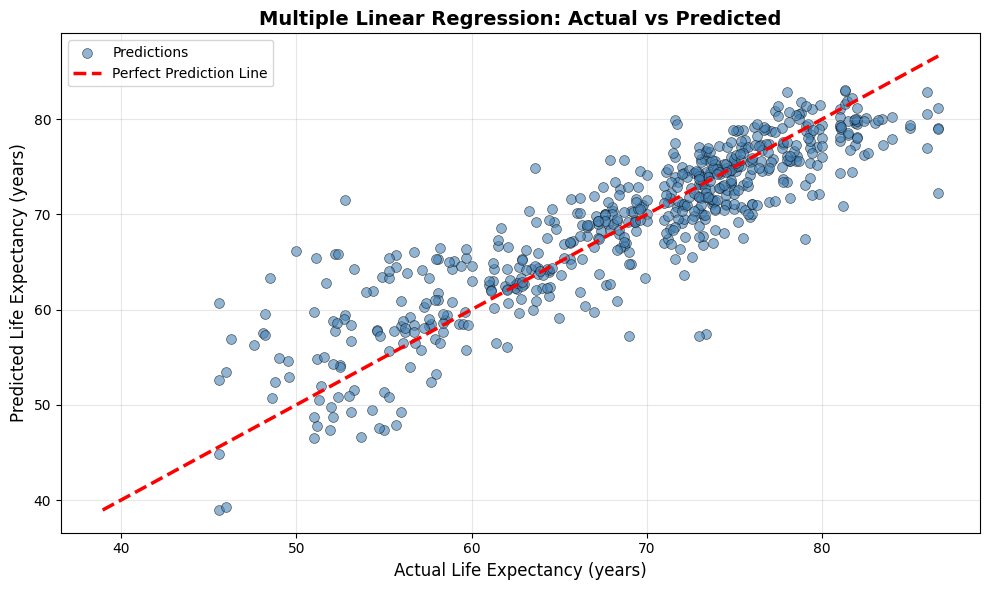

In [ ]:
plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred, alpha=0.6, s=50, color='steelblue',
            edgecolors='black', linewidth=0.5, label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5,
         label='Perfect Prediction Line')

plt.xlabel('Actual Life Expectancy (years)', fontsize=12)
plt.ylabel('Predicted Life Expectancy (years)', fontsize=12)
plt.title('Multiple Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multiple_regression_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()


## CELL 9: Visualization - Residual Plot

**Purpose**

Check for homoscedasticity (equal variance of residuals) and other assumption violations.

**Input**
- y_pred: Predicted values
- residuals: y_test - y_pred

**Output**
- Residual plot (saved as PNG)
- Residual statistics


**Line-by-Line Explanation**

**Identical concept to simple regression residual plot.**

**Key checks:**

1. **Mean ≈ 0:**
   - Indicates unbiased predictions
   - Not systematically over or underpredicting

2. **Random scatter:**
   - No funnel shape
   - No curve pattern
   - Equal spread across all predicted values

3. **Outliers:**
   - Points far from zero line
   - Indicate samples model struggles with

**Example output:**
```
Mean of residuals: -0.0001
  → Essentially zero ✓ (unbiased)
  
Std deviation of residuals: 5.12
  → Most errors within ±10.24 years (±2 std devs)
```

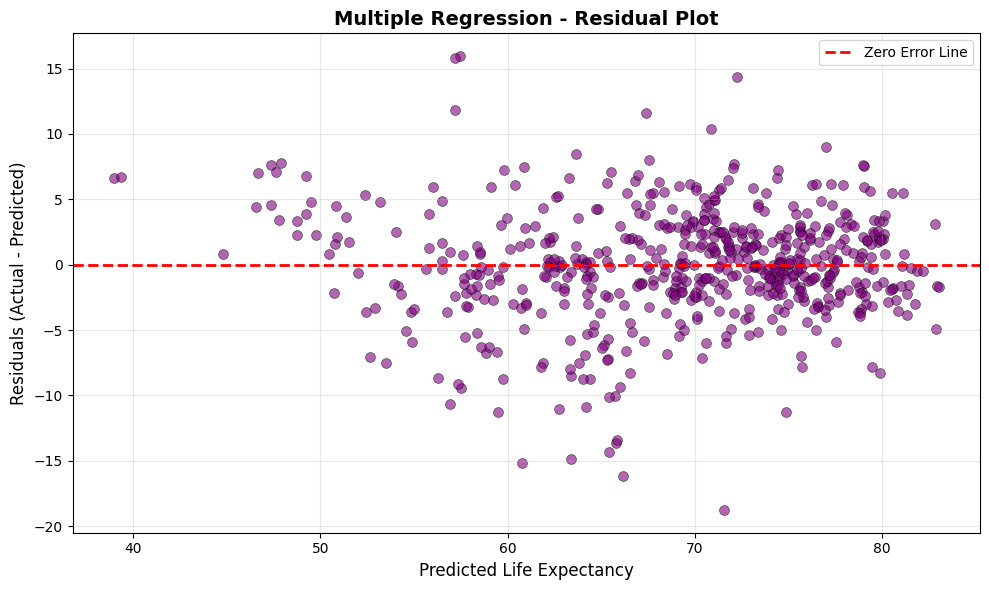

Mean of residuals: -0.1097
Std deviation of residuals: 4.2607


In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

plt.scatter(y_pred, residuals, alpha=0.6, s=50, color='purple',
            edgecolors='black', linewidth=0.5)

plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

plt.xlabel('Predicted Life Expectancy', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Multiple Regression - Residual Plot', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('multiple_regression_residual_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Mean of residuals: {residuals.mean():.4f}")
print(f"Std deviation of residuals: {residuals.std():.4f}")


## CELL 10: Visualization - Coefficients Bar Chart

**Purpose**

Visually show which coefficients are positive/negative and their relative magnitudes.

**Input**
- Coefficients array
- Feature names

**Output**
- Horizontal bar chart (saved as PNG)



**Line-by-Line Explanation**

1. `colors = ['green' if c > 0 else 'red' for c in coefficients]`
   - List comprehension creating color for each coefficient
   - Green = positive (beneficial factor)
   - Red = negative (harmful factor)

2. `plt.barh(predictor_features, coefficients, color=colors, ...)`
   - Horizontal bar chart
   - y-axis: Feature names
   - x-axis: Coefficient values
   - Bar length = coefficient magnitude
   - Bar color = coefficient sign

3. `plt.axvline(x=0, color='black', linestyle='-', linewidth=1)`
   - Vertical line at x=0
   - Separates positive from negative

**What you'll see:**
```
Features
                                |
Schooling          [====green====]|→ Positive
Income comp   [======green=======]|→ Positive (largest)
Adult Mort    |←[red]=============  Negative
HIV/AIDS      |←[red]=========      Negative
BMI              [=green=]|→        Positive (small)
                                |
        -2.0  -1.0   0.0   1.0   2.0  ...
              Coefficient Value
```

**Quick interpretation:**
- Longest bars = largest impact
- Green bars to right = increase life expectancy
- Red bars to left = decrease life expectancy
- Bars near zero line = small impact

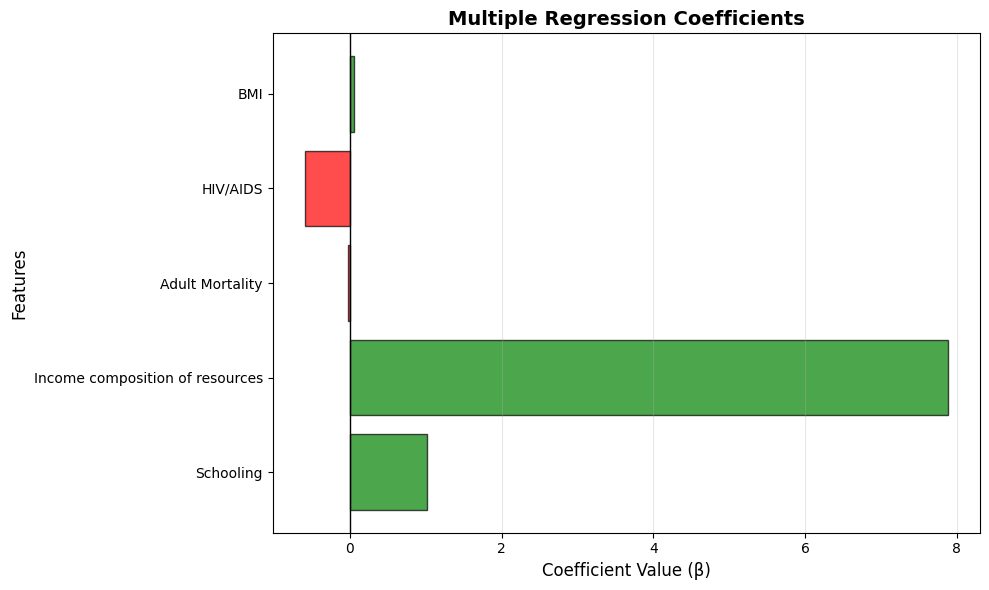

In [ ]:
plt.figure(figsize=(10, 6))

colors = ['green' if c > 0 else 'red' for c in coefficients]
plt.barh(predictor_features, coefficients, color=colors, alpha=0.7, edgecolor='black')

plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.xlabel('Coefficient Value (β)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Multiple Regression Coefficients', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('multiple_regression_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()


## CELL 11: Compare Simple vs Multiple Regression

**Purpose**

Quantify improvement from adding more features.

**Input**
- Simple regression R² and RMSE (from your earlier work)
- Multiple regression R² and RMSE

**Output**
- Comparison table
- Improvement percentage



**Line-by-Line Explanation**

1. `simple_r2 = 0.5356`
   - **YOU MUST CHANGE THIS** to your actual simple regression R²
   - Get this from Cell 6 output of your simple regression

2. `simple_rmse = 6.3120`
   - **YOU MUST CHANGE THIS** to your actual simple regression RMSE

3. Comparison table prints side-by-side results

4. `improvement_pct = ((r2 - simple_r2) / simple_r2) * 100`
   - Calculate percentage improvement in R²
   - Formula: (new - old) / old × 100

**Example output:**
```
Metric                         Simple Regression    Multiple Regression  Improvement
R² Score                       0.5356               0.6842               +0.1486
RMSE (years)                   6.3120               5.1200               -1.1920

✓ R² improvement: +27.73%
✓ Multiple regression explains 14.86% MORE variance
```

**Interpretation:**
- R² increased from 53.56% to 68.42%
- This is a 27.73% relative improvement
- RMSE decreased by 1.19 years (better predictions)
- The 4 additional features contributed meaningful information

**Expected Results:**
- Multiple R² should be higher (or equal at worst)
- Multiple RMSE should be lower (or equal at worst)
- If multiple performs worse, something is wrong (check for errors)

**Diminishing Returns:**
- First few features add most value
- Each additional feature adds less incremental improvement
- Eventually, adding more features risks overfitting

In [ ]:

simple_r2 = 0.5356  # YOUR simple regression R²
simple_rmse = 6.3120  # YOUR simple regression RMSE

print(f"{'Metric':<30} {'Simple Regression':<20} {'Multiple Regression':<20} {'Improvement'}")
print(f"{'R² Score':<30} {simple_r2:<20.4f} {r2:<20.4f} {'+' if r2 > simple_r2 else ''}{(r2 - simple_r2):.4f}")
print(f"{'RMSE (years)':<30} {simple_rmse:<20.4f} {rmse:<20.4f} {'-' if rmse < simple_rmse else '+'}{abs(rmse - simple_rmse):.4f}")

improvement_pct = ((r2 - simple_r2) / simple_r2) * 100
print(f"\n✓ R² improvement: {improvement_pct:+.2f}%")

if r2 > simple_r2:
    print(f"✓ Multiple regression explains {(r2 - simple_r2)*100:.2f}% MORE variance")

Metric                         Simple Regression    Multiple Regression  Improvement
R² Score                       0.5356               0.7884               +0.2528
RMSE (years)                   6.3120               4.2621               -2.0499

✓ R² improvement: +47.21%
✓ Multiple regression explains 25.28% MORE variance



## CELL 12: Summary Report

**Purpose**
Compile all findings into comprehensive summary.

**Input**
- All calculated metrics and parameters

**Output**
- Complete summary for IEEE report



**Line-by-Line Explanation**

**Compiles everything into one place:**
- Model specification (which features used)
- Full equation with all coefficients
- Dataset split information
- All performance metrics
- Feature importance ranking

In [ ]:

print("\n" + "="*70)
print("MULTIPLE LINEAR REGRESSION - SUMMARY REPORT")
print("="*70)

print(f"\nModel: Life expectancy ~ {' + '.join(predictor_features)}")

print(f"\nEquation:")
equation = f"Life expectancy = {intercept:.2f}"
for feature, coef in zip(predictor_features, coefficients):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign} {coef:.2f}×{feature}"
print(f"  {equation}")

print(f"\nDataset:")
print(f"  - Total samples: {len(X)}")
print(f"  - Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  - Number of predictors: {len(predictor_features)}")

print(f"\nPerformance on Test Set:")
print(f"  - R²: {r2:.4f} ({r2*100:.2f}% variance explained)")
print(f"  - RMSE: {rmse:.4f} years")
print(f"  - MAE: {mae:.4f} years")
print(f"  - MSE: {mse:.4f}")

print(f"\nMost Important Features (by |coefficient|):")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {row['Feature']}: β = {row['Coefficient']:.4f}")


MULTIPLE LINEAR REGRESSION - SUMMARY REPORT

Model: Life expectancy ~ Schooling + Income composition of resources + Adult Mortality + HIV/AIDS + BMI

Equation:
  Life expectancy = 54.42 + 1.01×Schooling + 7.88×Income composition of resources  -0.02×Adult Mortality  -0.60×HIV/AIDS + 0.06×BMI

Dataset:
  - Total samples: 2938
  - Training samples: 2350 (80.0%)
  - Testing samples: 588 (20.0%)
  - Number of predictors: 5

Performance on Test Set:
  - R²: 0.7884 (78.84% variance explained)
  - RMSE: 4.2621 years
  - MAE: 3.1336 years
  - MSE: 18.1655

Most Important Features (by |coefficient|):
  Income composition of resources: β = 7.8825
  Schooling: β = 1.0113
  HIV/AIDS: β = -0.5974



## CELL 13: Save Results to Files

**Purpose**

Export all results for IEEE report and future reference.

**Input**
- All calculated metrics, coefficients, and predictions

**Output**
- 3 CSV files with results

**Line-by-Line Explanation**

**File 1: Metrics CSV**
- Table with R², MSE, RMSE, MAE
- Easy to copy into IEEE report

**Output:**
```csv
Metric,Value
R² Score,0.6842
MSE,26.2144
RMSE,5.1200
MAE,4.0156
Intercept,35.2100
```

**File 2: Coefficients CSV**
- Table with all coefficients
- Shows contribution of each feature

**Output:**
```csv
Feature,Coefficient
Intercept,35.2100
Schooling,2.1800
Income composition of resources,15.3400
Adult Mortality,-0.0200
HIV/AIDS,-1.2300
BMI,0.1500
```

**File 3: Predictions CSV**
- Detailed predictions for all test samples
- Includes all feature values, actual, predicted, residual

**Output:**
```csv
Schooling,Income composition,Adult Mortality,HIV/AIDS,BMI,Actual_Life_Expectancy,Predicted_Life_Expectancy,Residual
12.5,0.76,180,0.3,24.2,74.80,73.78,1.02
8.9,0.45,320,1.2,19.8,56.70,58.34,-1.64
...
```

**Why save these?**
- **Metrics:** Quick reference for report
- **Coefficients:** Can analyze which features matter
- **Predictions:** Can identify worst predictions, verify calculations


In [ ]:
# Save metrics
results_df = pd.DataFrame({
    'Metric': ['R² Score', 'MSE', 'RMSE', 'MAE', 'Intercept'],
    'Value': [r2, mse, rmse, mae, intercept]
})
results_df.to_csv('multiple_regression_results.csv', index=False)

# Save coefficients
coefficients_df = pd.DataFrame({
    'Feature': ['Intercept'] + predictor_features,
    'Coefficient': [intercept] + list(coefficients)
})
coefficients_df.to_csv('multiple_regression_coefficients.csv', index=False)

# Save predictions
predictions_df = pd.DataFrame(X_test, columns=predictor_features)
predictions_df['Actual_Life_Expectancy'] = y_test
predictions_df['Predicted_Life_Expectancy'] = y_pred
predictions_df['Residual'] = residuals
predictions_df.to_csv('multiple_regression_predictions.csv', index=False)


## **Complete Workflow Summary**

```
1. Load Data + Select Multiple Predictors
   → Extract 3-5 highly correlated features
   
2. Split Data
   → 80/20 train/test (same random_state as simple)
   
3. Train Model
   → Learn β₀ + all βᵢ coefficients
   
4. Extract Coefficients
   → Get full equation with all terms
   
5. Make Predictions
   → Apply equation to test data
   
6. Calculate Metrics
   → R², MSE, RMSE, MAE
   
7. Rank Feature Importance
   → Which features have largest coefficients?
   
8. Visualize: Actual vs Predicted
   → Check overall fit quality
   
9. Visualize: Residuals
   → Check assumptions
   
10. Visualize: Coefficients
    → Bar chart of positive/negative effects
    
11. Compare to Simple Regression
    → Quantify improvement
    
12. Summarize
    → Compile all findings
    
13. Save Results
    → Export to CSV for report
```


## **Key Concepts Recap**

### **Multiple Linear Regression**
- Uses multiple predictors simultaneously
- Equation: y = β₀ + β₁×X₁ + β₂×X₂ + ...
- Each coefficient shows ISOLATED effect (holding others constant)

### **Interpreting Coefficients**
- βᵢ = change in y per 1-unit increase in Xᵢ, **holding all other variables constant**
- This is KEY difference from correlation
- Positive β = beneficial factor
- Negative β = harmful factor

### **Why Multiple > Simple?**
- Captures combined effects of multiple factors
- Controls for confounding variables
- Usually explains more variance (higher R²)
- More realistic (life expectancy depends on many factors, not just one)

### **Feature Importance**
- Larger |β| = larger impact per unit
- But coefficients not directly comparable across different scales
- Feature with large coefficient might have small practical impact if its range is small

### **Model Comparison**
- Multiple R² ≥ Simple R² (always, mathematically)
- Multiple RMSE should be ≤ Simple RMSE (usually)
- Improvement shows value of additional features


#Multiple Linear Regression Whole code

MULTIPLE LINEAR REGRESSION - DATA PREPARATION

Target Variable: Life expectancy

Predictor Variables (5):
  1. Schooling
  2. Income composition of resources
  3. Adult Mortality
  4. HIV/AIDS
  5. BMI

Dataset shape: (2938, 19)
X shape: (2938, 5)
y shape: (2938, 1)

TRAIN-TEST SPLIT
Training set: 2350 samples (80.0%)
Testing set: 588 samples (20.0%)

MODEL TRAINING COMPLETE
✓ Multiple Linear Regression model trained on 2350 samples
✓ Using 5 predictor variables

MODEL COEFFICIENTS AND INTERPRETATION

Regression Equation:
Life expectancy = 54.42 + 1.01×Schooling + 7.88×Income composition of resources  -0.02×Adult Mortality  -0.60×HIV/AIDS + 0.06×BMI

Feature                                  Coefficient (β) Interpretation
----------------------------------------------------------------------------------------------------
Intercept (β₀)                           54.4209         Baseline life expectancy
Schooling                                1.0113          ↑ 1.01 years per unit
Income 

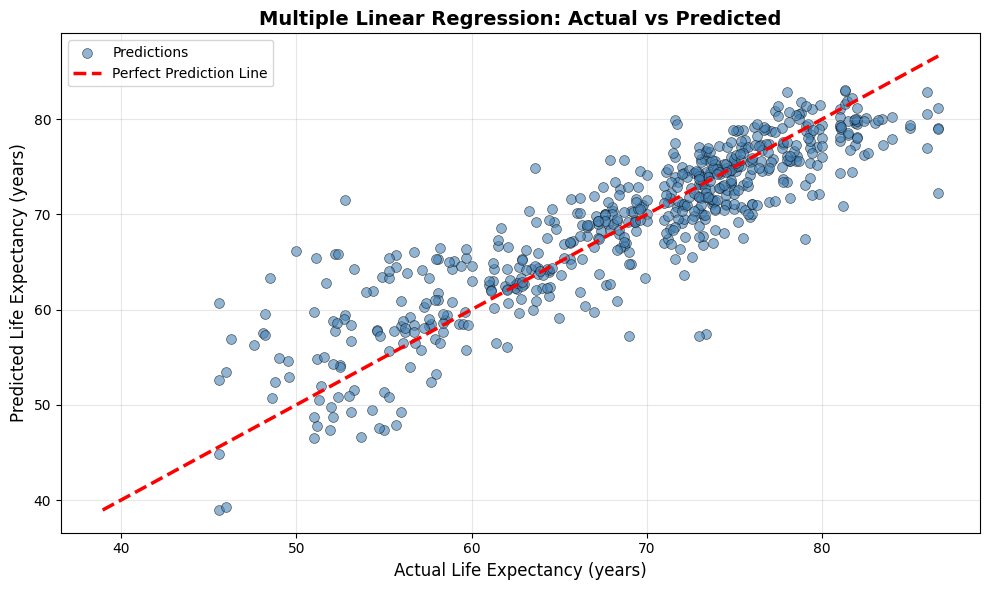

✓ Residual plot saved as 'multiple_regression_residual_plot.png'


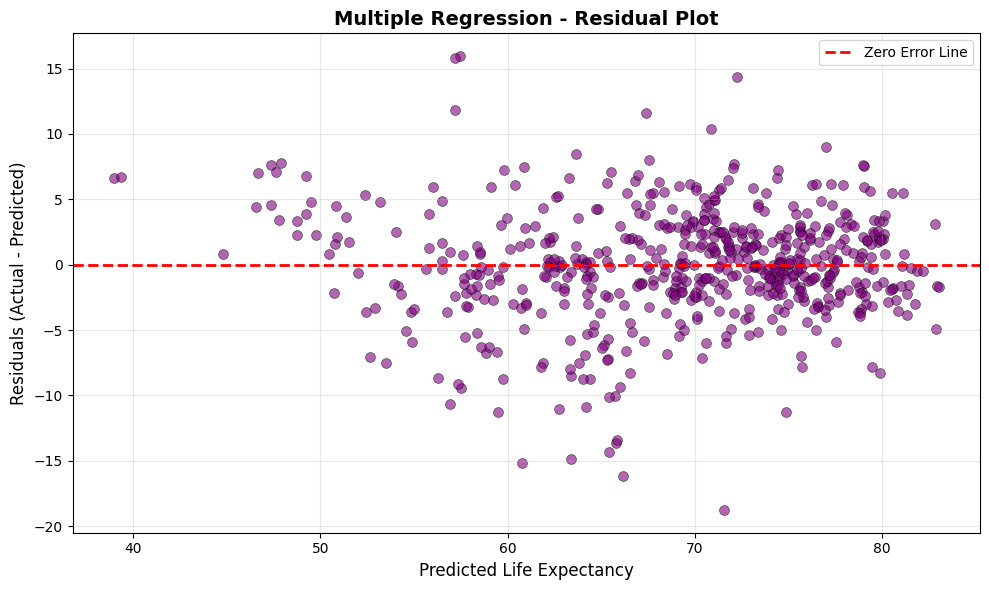


RESIDUAL ANALYSIS
Mean of residuals: -0.1097
  → Should be close to 0 (indicates unbiased predictions)
Std deviation of residuals: 4.2607
  → Measures spread of errors
✓ Coefficients bar chart saved as 'multiple_regression_coefficients.png'


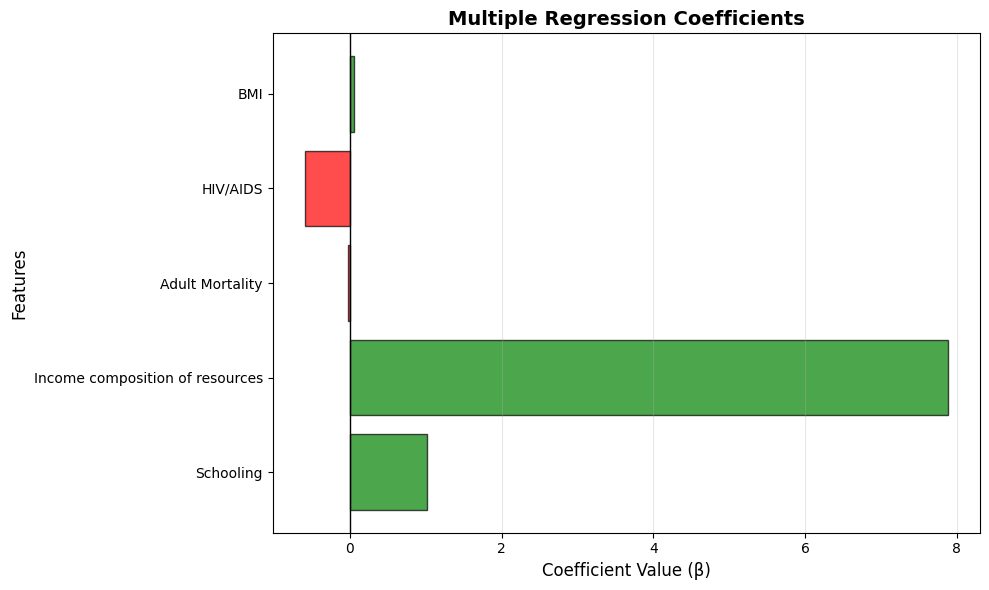


COMPARISON: SIMPLE vs MULTIPLE REGRESSION

Metric                         Simple Regression    Multiple Regression  Improvement
------------------------------------------------------------------------------------------
R² Score                       0.5669               0.7884               +0.2215
RMSE (years)                   6.0982               4.2621               -1.8361

✓ R² improvement: +39.08%
✓ Multiple regression explains 22.15% MORE variance

MULTIPLE LINEAR REGRESSION - SUMMARY REPORT

Model: Life expectancy ~ Schooling + Income composition of resources + Adult Mortality + HIV/AIDS + BMI

Equation:
  Life expectancy = 54.42 + 1.01×Schooling + 7.88×Income composition of resources  -0.02×Adult Mortality  -0.60×HIV/AIDS + 0.06×BMI

Dataset:
  - Total samples: 2938
  - Training samples: 2350 (80.0%)
  - Testing samples: 588 (20.0%)
  - Number of predictors: 5

Performance on Test Set:
  - R²: 0.7884 (78.84% variance explained)
  - RMSE: 4.2621 years
  - MAE: 3.1336 years
  

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

# Load the cleaned dataset
df = pd.read_csv('WHO_cleaned_data.csv')

# Define target
target = 'Life expectancy'

# Select top predictors based on correlation analysis
# CHANGE THESE to YOUR top 3-5 features from correlation analysis
# Include the feature you used in simple regression PLUS 2-4 more
predictor_features = [
    'Schooling',                           # Top 1 (used in simple regression)
    'Income composition of resources',     # Top 2
    'Adult Mortality',                     # Top 3
    'HIV/AIDS',                            # Top 4 (optional)
    'BMI'                                  # Top 5 (optional)
]

# Extract features and target
X = df[predictor_features].values  # Multiple predictors (2D array)
y = df[target].values.reshape(-1, 1)  # Target (2D array)

print("="*70)
print("MULTIPLE LINEAR REGRESSION - DATA PREPARATION")
print("="*70)
print(f"\nTarget Variable: {target}")
print(f"\nPredictor Variables ({len(predictor_features)}):")
for i, feature in enumerate(predictor_features, 1):
    print(f"  {i}. {feature}")

print(f"\nDataset shape: {df.shape}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Split: 80% training, 20% testing
# Use same random_state as simple regression for fair comparison
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\n" + "="*70)
print("TRAIN-TEST SPLIT")
print("="*70)
print(f"Training set: {X_train.shape[0]} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Testing set: {X_test.shape[0]} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

# Create and train model
model_multiple = LinearRegression()
model_multiple.fit(X_train, y_train)

print("\n" + "="*70)
print("MODEL TRAINING COMPLETE")
print("="*70)
print(f"✓ Multiple Linear Regression model trained on {X_train.shape[0]} samples")
print(f"✓ Using {X_train.shape[1]} predictor variables")

# Get coefficients and intercept
coefficients = model_multiple.coef_[0]  # Array of slopes (one per feature)
intercept = model_multiple.intercept_[0]  # Intercept

print("\n" + "="*70)
print("MODEL COEFFICIENTS AND INTERPRETATION")
print("="*70)

# Display regression equation
print(f"\nRegression Equation:")
equation = f"Life expectancy = {intercept:.2f}"
for i, (feature, coef) in enumerate(zip(predictor_features, coefficients)):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign} {coef:.2f}×{feature}"
print(equation)

# Display coefficients table
print(f"\n{'Feature':<40} {'Coefficient (β)':<15} {'Interpretation'}")
print("-" * 100)

print(f"{'Intercept (β₀)':<40} {intercept:<15.4f} Baseline life expectancy")

for feature, coef in zip(predictor_features, coefficients):
    interpretation = f"{'↑' if coef > 0 else '↓'} {abs(coef):.2f} years per unit"
    print(f"{feature:<40} {coef:<15.4f} {interpretation}")

# Detailed interpretation
print("\n" + "="*70)
print("COEFFICIENT INTERPRETATION (holding other features constant)")
print("="*70)

for feature, coef in zip(predictor_features, coefficients):
    if coef > 0:
        print(f"\n{feature}:")
        print(f"  → A 1-unit increase in {feature} is associated with")
        print(f"     a {coef:.2f}-year INCREASE in life expectancy")
        print(f"     (while holding all other features constant)")
    else:
        print(f"\n{feature}:")
        print(f"  → A 1-unit increase in {feature} is associated with")
        print(f"     a {abs(coef):.2f}-year DECREASE in life expectancy")
        print(f"     (while holding all other features constant)")


# Predict on test data
y_pred = model_multiple.predict(X_test)

print("\n" + "="*70)
print("PREDICTIONS ON TEST SET")
print("="*70)
print(f"Number of predictions: {len(y_pred)}")

# Show first 5 predictions with all feature values
print(f"\nFirst 5 predictions (showing all features):")
print("-" * 100)
header = "Actual  Predicted  Error  "
for feature in predictor_features:
    header += f"{feature[:12]:<12} "
print(header)
print("-" * 100)

for i in range(min(5, len(y_test))):
    error = y_test[i][0] - y_pred[i][0]
    row = f"{y_test[i][0]:6.2f}  {y_pred[i][0]:9.2f}  {error:5.2f}  "
    for j in range(len(predictor_features)):
        row += f"{X_test[i][j]:<12.2f} "
    print(row)


# Calculate all metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)

print("\n" + "="*70)
print("MODEL PERFORMANCE METRICS (TEST SET)")
print("="*70)

print(f"\n1. R² (R-squared) Score: {r2:.4f}")
print(f"   → Model explains {r2*100:.2f}% of variance in life expectancy")
if r2 > 0.7:
    print(f"   → Interpretation: Strong model (R² > 0.7)")
elif r2 > 0.5:
    print(f"   → Interpretation: Moderate model (0.5 < R² < 0.7)")
else:
    print(f"   → Interpretation: Weak model (R² < 0.5)")

print(f"\n2. Mean Squared Error (MSE): {mse:.4f}")

print(f"\n3. Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"   → On average, predictions are off by ±{rmse:.2f} years")

print(f"\n4. Mean Absolute Error (MAE): {mae:.4f}")
print(f"   → On average, absolute prediction error is {mae:.2f} years")


# Rank features by absolute coefficient value
feature_importance = pd.DataFrame({
    'Feature': predictor_features,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print("\n" + "="*70)
print("FEATURE IMPORTANCE (by coefficient magnitude)")
print("="*70)
print("\nFeatures ranked by impact on Life Expectancy:")
print("-" * 70)

for idx, row in feature_importance.iterrows():
    impact = "↑ Increases" if row['Coefficient'] > 0 else "↓ Decreases"
    print(f"{row['Feature']:<40} {impact} by {abs(row['Coefficient']):.4f} years/unit")


plt.figure(figsize=(10, 6))

# Scatter plot: actual vs predicted
plt.scatter(y_test, y_pred, alpha=0.6, s=50, color='steelblue',
            edgecolors='black', linewidth=0.5, label='Predictions')

# Perfect prediction line (y = x)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2.5,
         label='Perfect Prediction Line')

plt.xlabel('Actual Life Expectancy (years)', fontsize=12)
plt.ylabel('Predicted Life Expectancy (years)', fontsize=12)
plt.title('Multiple Linear Regression: Actual vs Predicted', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('multiple_regression_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print("\n✓ Actual vs Predicted plot saved as 'multiple_regression_actual_vs_predicted.png'")
plt.show()


# Calculate residuals
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))

# Scatter plot of residuals
plt.scatter(y_pred, residuals, alpha=0.6, s=50, color='purple',
            edgecolors='black', linewidth=0.5)

# Zero line
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Zero Error Line')

plt.xlabel('Predicted Life Expectancy', fontsize=12)
plt.ylabel('Residuals (Actual - Predicted)', fontsize=12)
plt.title('Multiple Regression - Residual Plot', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig('multiple_regression_residual_plot.png', dpi=300, bbox_inches='tight')
print("✓ Residual plot saved as 'multiple_regression_residual_plot.png'")
plt.show()

# Residual statistics
print("\n" + "="*70)
print("RESIDUAL ANALYSIS")
print("="*70)
print(f"Mean of residuals: {residuals.mean():.4f}")
print(f"  → Should be close to 0 (indicates unbiased predictions)")
print(f"Std deviation of residuals: {residuals.std():.4f}")
print(f"  → Measures spread of errors")


plt.figure(figsize=(10, 6))

# Create bar chart of coefficients
colors = ['green' if c > 0 else 'red' for c in coefficients]
plt.barh(predictor_features, coefficients, color=colors, alpha=0.7, edgecolor='black')

# Zero line
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.xlabel('Coefficient Value (β)', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Multiple Regression Coefficients', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

plt.savefig('multiple_regression_coefficients.png', dpi=300, bbox_inches='tight')
print("✓ Coefficients bar chart saved as 'multiple_regression_coefficients.png'")
plt.show()

# If you ran simple regression first and have the results, compare here
# You'll need to manually input your simple regression R² value

print("\n" + "="*70)
print("COMPARISON: SIMPLE vs MULTIPLE REGRESSION")
print("="*70)

# REPLACE these with your actual simple regression results
simple_r2 = 0.5669  # Change this to YOUR simple regression R²
simple_rmse = 6.0982 # Change this to YOUR simple regression RMSE

print(f"\n{'Metric':<30} {'Simple Regression':<20} {'Multiple Regression':<20} {'Improvement'}")
print("-" * 90)
print(f"{'R² Score':<30} {simple_r2:<20.4f} {r2:<20.4f} {'+' if r2 > simple_r2 else ''}{(r2 - simple_r2):.4f}")
print(f"{'RMSE (years)':<30} {simple_rmse:<20.4f} {rmse:<20.4f} {'-' if rmse < simple_rmse else '+'}{abs(rmse - simple_rmse):.4f}")

improvement_pct = ((r2 - simple_r2) / simple_r2) * 100
print(f"\n✓ R² improvement: {improvement_pct:+.2f}%")

if r2 > simple_r2:
    print(f"✓ Multiple regression explains {(r2 - simple_r2)*100:.2f}% MORE variance")
else:
    print(f"⚠ Simple regression performed better (possible overfitting)")

print("\n" + "="*70)
print("MULTIPLE LINEAR REGRESSION - SUMMARY REPORT")
print("="*70)

print(f"\nModel: Life expectancy ~ {' + '.join(predictor_features)}")

print(f"\nEquation:")
equation = f"Life expectancy = {intercept:.2f}"
for feature, coef in zip(predictor_features, coefficients):
    sign = "+" if coef >= 0 else ""
    equation += f" {sign} {coef:.2f}×{feature}"
print(f"  {equation}")

print(f"\nDataset:")
print(f"  - Total samples: {len(X)}")
print(f"  - Training samples: {len(X_train)} ({len(X_train)/len(X)*100:.1f}%)")
print(f"  - Testing samples: {len(X_test)} ({len(X_test)/len(X)*100:.1f}%)")
print(f"  - Number of predictors: {len(predictor_features)}")

print(f"\nPerformance on Test Set:")
print(f"  - R²: {r2:.4f} ({r2*100:.2f}% variance explained)")
print(f"  - RMSE: {rmse:.4f} years")
print(f"  - MAE: {mae:.4f} years")
print(f"  - MSE: {mse:.4f}")

print(f"\nMost Important Features (by |coefficient|):")
for i, row in feature_importance.head(3).iterrows():
    print(f"  {row['Feature']}: β = {row['Coefficient']:.4f}")

print("="*70)


# Save metrics
results_df = pd.DataFrame({
    'Metric': ['R² Score', 'MSE', 'RMSE', 'MAE', 'Intercept'],
    'Value': [r2, mse, rmse, mae, intercept]
})
results_df.to_csv('multiple_regression_results.csv', index=False)
print("\n✓ Results saved as 'multiple_regression_results.csv'")

# Save coefficients
coefficients_df = pd.DataFrame({
    'Feature': ['Intercept'] + predictor_features,
    'Coefficient': [intercept] + list(coefficients)
})
coefficients_df.to_csv('multiple_regression_coefficients.csv', index=False)
print("✓ Coefficients saved as 'multiple_regression_coefficients.csv'")

# Save predictions
predictions_df = pd.DataFrame(X_test, columns=predictor_features)
predictions_df['Actual_Life_Expectancy'] = y_test
predictions_df['Predicted_Life_Expectancy'] = y_pred
predictions_df['Residual'] = residuals
predictions_df.to_csv('multiple_regression_predictions.csv', index=False)
print("✓ Predictions saved as 'multiple_regression_predictions.csv'")

print("\nAll files generated:")

print("  1. multiple_regression_actual_vs_predicted.png")
print("  2. multiple_regression_residual_plot.png")
print("  3. multiple_regression_coefficients.png")
print("  4. multiple_regression_results.csv")
print("  5. multiple_regression_coefficients.csv")
print("  6. multiple_regression_predictions.csv")

#Simple Linear Regression Predictions for Life Expectancy data of WHO

## Cell 1: Setup Predictor*

In [ ]:
print("\n" + "="*70)
print("LIFE EXPECTANCY PREDICTOR - INTERACTIVE MODE")
print("="*70)
print(f"\nModel trained: Life expectancy = {intercept:.2f} + {coefficient:.2f} × {predictor_feature}")
print(f"\nEnter a value for {predictor_feature} to predict Life Expectancy.")
print("Type 'exit' to close the program.")
print("-"*70)


LIFE EXPECTANCY PREDICTOR - INTERACTIVE MODE

Model trained: Life expectancy = 54.42 + 2.18 × Schooling

Enter a value for Schooling to predict Life Expectancy.
Type 'exit' to close the program.
----------------------------------------------------------------------


##Cell 2: Interactive Loop


**Line-by-Line Explanation:**

1. `print(f"\nModel trained: Life expectancy = {intercept:.2f} + {coefficient:.2f} × {predictor_feature}")`
   - Shows the learned equation so user knows what model they're using
   - Inserts actual coefficient values

2. `user_input = input(f"\nEnter {predictor_feature} value: ")`
   - Prompts user with specific feature name (e.g., "Enter Schooling value:")
   - Waits for user to type and press Enter
   - Returns input as string

3. `if user_input.lower() == 'exit':`
   - `.lower()` converts input to lowercase ("EXIT" → "exit")
   - Allows user to exit with "exit", "Exit", "EXIT", etc.

4. `x_new = float(user_input)`
   - Convert string to number
   - Example: "12.5" → 12.5
   - Raises ValueError if input is non-numeric (caught by try-except)

5. `x_val = np.array([[x_new]])`
   - Create 2D NumPy array with shape (1, 1)
   - Sklearn requires 2D: [[12.5]] not [12.5]

6. `y_val = model.predict(x_val)`
   - Apply trained model to new input
   - Calculates: ŷ = β₀ + β₁ × x_new
   - Returns 2D array: [[predicted_value]]

7. `predicted_life_expectancy = y_val[0][0]`
   - Extract the actual number from 2D array
   - `[0]` gets first row, `[0]` gets first column
   - [[70.54]] → 70.54

8. `manual_calc = intercept + coefficient * x_new`
   - Manually calculate prediction to show the math
   - Same result as model.predict(), but shows formula

9. Context interpretation (optional):
   - Provides meaningful ranges
   - Helps user understand if prediction is realistic

10. `except ValueError:`
    - Catches errors when user enters non-numeric input
    - Example: "abc" or "hello" → ValueError

---

## **Example Usage:**
```
======================================================================
LIFE EXPECTANCY PREDICTOR - INTERACTIVE MODE
======================================================================

Model trained: Life expectancy = 43.29 + 2.18 × Schooling

Enter a value for Schooling to predict Life Expectancy.
Type 'exit' to close the program.
----------------------------------------------------------------------

Enter Schooling value: 10

----------------------------------------------------------------------
>>> Input: Schooling = 10.00
>>> Predicted Life Expectancy: 65.09 years
>>> Calculation: 43.29 + 2.18 × 10.00 = 65.09
>>> Context: Below average life expectancy
----------------------------------------------------------------------

Enter Schooling value: 15

----------------------------------------------------------------------
>>> Input: Schooling = 15.00
>>> Predicted Life Expectancy: 75.99 years
>>> Calculation: 43.29 + 2.18 × 15.00 = 75.99
>>> Context: Above average life expectancy
----------------------------------------------------------------------

Enter Schooling value: abc

❌ Invalid input! Please enter a numerical value.
   Example: If testing Schooling, try values like 10.5 or 15.2

Enter Schooling value: exit

In [ ]:
while True:
    user_input = input(f"\nEnter {predictor_feature} value: ")

    if user_input.lower() == 'exit':
        print("\nThank you for using the Life Expectancy Predictor!")
        break

    try:
        x_new = float(user_input)
        x_val = np.array([[x_new]])
        y_val = model.predict(x_val)
        predicted_life_expectancy = y_val[0][0]

        print("-"*70)
        print(f">>> Input: {predictor_feature} = {x_new:.2f}")
        print(f">>> Predicted Life Expectancy: {predicted_life_expectancy:.2f} years")
        print(f">>> Calculation: {intercept:.2f} + {coefficient:.2f} × {x_new:.2f} = {intercept + coefficient * x_new:.2f}")
        print("-"*70)

    except ValueError:
        print("❌ Invalid input! Please enter a numerical value.")


Enter Schooling value: 10.0
----------------------------------------------------------------------
>>> Input: Schooling = 10.00
>>> Predicted Life Expectancy: 64.79 years
>>> Calculation: 54.42 + 2.18 × 10.00 = 76.26
----------------------------------------------------------------------

Enter Schooling value: 100
----------------------------------------------------------------------
>>> Input: Schooling = 100.00
>>> Predicted Life Expectancy: 261.37 years
>>> Calculation: 54.42 + 2.18 × 100.00 = 272.85
----------------------------------------------------------------------

Enter Schooling value: 30
----------------------------------------------------------------------
>>> Input: Schooling = 30.00
>>> Predicted Life Expectancy: 108.47 years
>>> Calculation: 54.42 + 2.18 × 30.00 = 119.95
----------------------------------------------------------------------


KeyboardInterrupt: Interrupted by user

#Simple Linear Regression Predictions  for Life Expectancy data of WHO

In [ ]:

print("\n" + "="*70)
print("LIFE EXPECTANCY PREDICTOR - INTERACTIVE MODE")
print("="*70)
print(f"\nModel trained: Life expectancy = {intercept:.2f} + {coefficient:.2f} × {predictor_feature}")
print(f"\nEnter a value for {predictor_feature} to predict Life Expectancy.")
print("Type 'exit' to close the program.")
print("-"*70)

while True:
    # Prompt user for input
    user_input = input(f"\nEnter {predictor_feature} value: ")

    # Check if user wants to exit
    if user_input.lower() == 'exit':
        print("\n" + "="*70)
        print("Thank you for using the Life Expectancy Predictor!")
        print("="*70)
        break

    try:
        # Convert input to float
        x_new = float(user_input)

        # Reshape for model (sklearn requires 2D array)
        x_val = np.array([[x_new]])

        # Make prediction using trained model
        y_val = model.predict(x_val)

        # Extract predicted value
        predicted_life_expectancy = y_val[0][0]

        # Display result
        print("-"*70)
        print(f">>> Input: {predictor_feature} = {x_new:.2f}")
        print(f">>> Predicted Life Expectancy: {predicted_life_expectancy:.2f} years")

        # Show calculation breakdown
        manual_calc = intercept + coefficient * x_new
        print(f">>> Calculation: {intercept:.2f} + {coefficient:.2f} × {x_new:.2f} = {manual_calc:.2f}")

        # Provide context (optional - helpful interpretation)
        if predicted_life_expectancy < 50:
            print(">>> Context: Very low life expectancy (critical)")
        elif predicted_life_expectancy < 65:
            print(">>> Context: Below average life expectancy")
        elif predicted_life_expectancy < 75:
            print(">>> Context: Average life expectancy")
        elif predicted_life_expectancy < 85:
            print(">>> Context: Above average life expectancy")
        else:
            print(">>> Context: Exceptionally high life expectancy")

        print("-"*70)

    except ValueError:
        # Handle non-numeric input
        print("❌ Invalid input! Please enter a numerical value.")
        print(f"   Example: If testing {predictor_feature}, try values like 10.5 or 15.2")


LIFE EXPECTANCY PREDICTOR - INTERACTIVE MODE

Model trained: Life expectancy = 54.42 + 2.18 × Schooling

Enter a value for Schooling to predict Life Expectancy.
Type 'exit' to close the program.
----------------------------------------------------------------------

Enter Schooling value: 30
----------------------------------------------------------------------
>>> Input: Schooling = 30.00
>>> Predicted Life Expectancy: 108.47 years
>>> Calculation: 54.42 + 2.18 × 30.00 = 119.95
>>> Context: Exceptionally high life expectancy
----------------------------------------------------------------------

Enter Schooling value: 10
----------------------------------------------------------------------
>>> Input: Schooling = 10.00
>>> Predicted Life Expectancy: 64.79 years
>>> Calculation: 54.42 + 2.18 × 10.00 = 76.26
>>> Context: Below average life expectancy
----------------------------------------------------------------------

Enter Schooling value: 20
---------------------------------------